# Import

In [2]:
# %pip install numpy
# %pip install scipy
# %pip install astropy
# %pip install matplotlib
# %pip install pandas
# %pip install seaborn
# %pip install scienceplots
# %pip install numba
# %pip install -U "ray[default]"

In [3]:
import numpy as np
import scipy.integrate as integ
import scipy.interpolate as i2
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)
from astropy import units as u
from astropy import constants as c

from shooting import *
import shootingres as shr
import shooting as sho

import scipy.optimize as o
try:
    import cPickle as pickle
except ImportError:
    import pickle
    
import seaborn as sns
sns.set_theme()
sns.set_style("white")
sns.set_style("ticks")
sns.set_style("ticks",{'axes.grid' : True})
sns.set_palette("colorblind")

import seaborn as sns
sns.set_theme()
sns.set_style("white")
sns.set_style("ticks")
sns.set_style("ticks",{'axes.grid' : True})
import scienceplots
plt.style.use('science')

f = 16

In [4]:
## SET CONSTANTS
rho = (1.0*10**19) * (2.0*1.6725*10**(-27))
mu_0 = 1.2566*10**(-6)

# Define Normalizations
r1 = 0.1

## Define OMEGA0:
bb = 10000
v0 = bb/np.sqrt(r1)
Omega0 = v0/r1

In [5]:
r1 = 0.1
r2 = 5
reso = 500
r = np.arange(1, 5, 24/reso)
q_mag = 1
guess = 0.39760350887860546+0.02203028300281025j
VA_N = 0.578*8/10
# VA_N = 0.30848

B0 = 0
Bz = VA_N*r1*Omega0*np.sqrt(rho*mu_0)*10000
# VA_N = 30/(r1*Omega0*np.sqrt(rho*mu_0)*10000)
print(VA_N)
print(Bz)
kn = 1
m = 1
k = kn*np.pi/(4)

## NOTE VA_N ~ 30G
# Define Normalizations
r1 = 0.1



0.4624
29.978811690584404


In [6]:
## GET ETA ARR
elecd_init_o = [1]
# elecd_init_o = [0]

elecd_init_c = [-2, -1, 0, 1]

# elecd_arr = [1E-6, 1E-5, 1E-4, 1E-3]
elecd_arr = [1E-6, 1E-5, 1E-4, 1E-3]
# elecd_arr = []
multip_arr = []

# discret = int(8) 
# for j in range(0, discret):
#     multip_arr.append((j+1)*10/(discret))

multip_arr = [0,1,2,3,4,5,6,7,8,9]

# print(multip_arr)

# for j in range(0, len(elecd_init_c)):
#     for k in range(0, len(multip_arr)):
#         elecd_arr.append(np.round(multip_arr[k]*10**(elecd_init_c[j]), np.abs(elecd_init_c[j])+1))
        
for j in range(0, len(elecd_init_c)):
    iter = 2
    for k in range(0, 9*int(iter)):
        elecd_arr.append(np.round((k/iter+1)*10**(elecd_init_c[j]), np.abs(elecd_init_c[j])+1))

for j in range(0, len(elecd_init_o)):
    iter = 10
    for k in range(0, 9*int(iter)):
        elecd_arr.append(np.round((k/iter+1)*10**(elecd_init_o[j]), np.abs(elecd_init_o[j])+1))

elecd_arr.append(100)



# elecd_arr.remove(np.round(int((1))*10**(-elecd_init_o[0]), elecd_init_o[0]))
print(elecd_arr)


[1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100]


In [7]:
# import matplotlib as mpl
# print(mpl.get_cachedir())

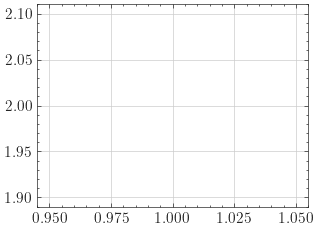

In [8]:
plt.figure()
x = [1,1]
y = [2,2]
plt.plot(x,y)
plt.show()

# WKB

In [9]:
elecd_str = '0'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-qprofs2-Bz.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-qprofs2-Bz.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-qprofs2-Bz.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-qprofs2-Bz.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

gr_1k1_MCI_l_Bz_qprofs2= []
gr_1k1_MCI_h_Bz_qprofs2 = []
for j in range(0,len(guesses_1k1_MCI_l) ):
    gr_1k1_MCI_l_Bz_qprofs2.append(guesses_1k1_MCI_l[j].imag)
    
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_qprofs2.append(guesses_1k1_MCI_h[j].imag)    

freq_1k1_MCI_l_Bz_qprofs2 = []
freq_1k1_MCI_h_Bz_qprofs2 = []
for j in range(0,len(guesses_1k1_MCI_l) ):
    freq_1k1_MCI_l_Bz_qprofs2.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h) ):
    freq_1k1_MCI_h_Bz_qprofs2.append(guesses_1k1_MCI_h[j].real)    
    
with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_qprofs2 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_qprofs2 = pickle.load(f)  

In [10]:
elecd_str = '50'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA50_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA50_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA50_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA50_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA50_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA50_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA50_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [11]:
elecd_str = '100'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA100_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA100_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA100_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA100_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA100_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA100_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA100_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA100_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA100_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA100_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [12]:
elecd_str = '200'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA200_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA200_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA200_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA200_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA200_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA200_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA200_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA200_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA200_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA200_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [13]:
elecd_str = '300'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA300_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA300_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA300_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA300_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA300_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA300_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA300_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA300_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA300_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA300_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [14]:
elecd_str = '400'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA400_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA400_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA400_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA400_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA400_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA400_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA400_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA400_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA400_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA400_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [15]:
elecd_str = '500'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA500_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA500_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA500_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA500_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA500_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA500_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA500_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA500_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA500_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA500_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [16]:
elecd_str = '600'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA600_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA600_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA600_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA600_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA600_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA600_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [17]:
elecd_str = '600'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA600_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA600_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA600_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA600_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA600_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA600_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA600_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [18]:
elecd_str = '700'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA700_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA700_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA700_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA700_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA700_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA700_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA700_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA700_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA700_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA700_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [19]:
elecd_str = '800'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA800_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA800_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA800_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA800_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA800_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA800_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA800_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA800_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA800_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA800_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

In [20]:
elecd_str = '1000'


guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

with open(guesses_str_d, 'rb') as f:
    guesses_1k1_MCI_l = pickle.load(f)    
with open(guesses_str_u, 'rb') as f:
    guesses_1k1_MCI_h = pickle.load(f)    

with open(VA_d, 'rb') as f:
    VA_l_MCI1_Bz_ETA1000_divr_WKB_div4 = pickle.load(f)    
with open(VA_u, 'rb') as f:
    VA_h_MCI1_Bz_ETA1000_divr_WKB_div4 = pickle.load(f)   
    
gr_1k1_MCI_l_Bz_ETA1000_divr_WKB_div4= []
gr_1k1_MCI_h_Bz_ETA1000_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    gr_1k1_MCI_l_Bz_ETA1000_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
for j in range(0,len(guesses_1k1_MCI_h) ):
    gr_1k1_MCI_h_Bz_ETA1000_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
freq_1k1_MCI_l_Bz_ETA1000_divr_WKB_div4 = []
freq_1k1_MCI_h_Bz_ETA1000_divr_WKB_div4 = []
for j in range(0,len(guesses_1k1_MCI_l)):
    freq_1k1_MCI_l_Bz_ETA1000_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
    
for j in range(0,len(guesses_1k1_MCI_h)):
    freq_1k1_MCI_h_Bz_ETA1000_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

# MCI MATCH WKB

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\O'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\O'
C:\Users\Alex\AppData\Local\Temp\ipykernel_122180\3774584884.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(VA_l_MCI1_Bz_qprofs2,gr_1k1_MCI_l_Bz_qprofs2, color = 'k', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 0$', linewidth=2)
C:\Users\Alex\AppData\Local\Temp\ipykernel_122180\3774584884.py:56: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)


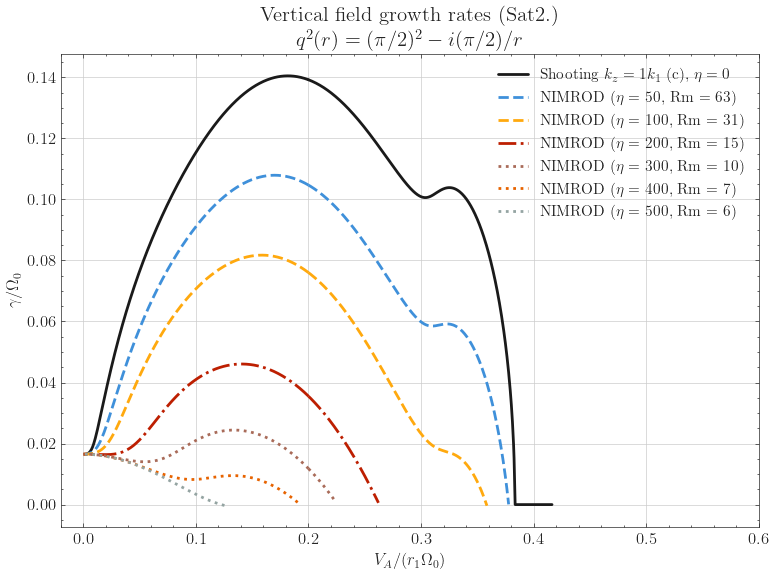

In [18]:
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']



### RESISTIVE SHOOTING DATA

# plt.plot(VA_l_MCI1_Bz_ETA2_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA2_divr_WKB_div4, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 5$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA2_divr_WKB_div4,gr_1k1_MCI_h_Bz_ETA2_divr_WKB_div4, 'k', linestyle = '--', linewidth=2)    
V0 = r1*Omega0
eta = [50, 100, 200, 300, 400, 500]
Rm = r1*V0/np.array(eta)


plt.plot(VA_l_MCI1_Bz_qprofs2,gr_1k1_MCI_l_Bz_qprofs2, color = 'k', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 0$', linewidth=2)
plt.plot(VA_h_MCI1_Bz_qprofs2[0:450],gr_1k1_MCI_h_Bz_qprofs2[0:450], color = 'k', linewidth=2)    

i = 0
plt.plot(VA_l_MCI1_Bz_ETA50_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA50_divr_WKB_div4, color = color_arr[0], linestyle = '--', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA50_divr_WKB_div4[0:370],gr_1k1_MCI_h_Bz_ETA50_divr_WKB_div4[0:370], color = color_arr[0], linestyle = '--', linewidth=2)    


i = 1
plt.plot(VA_l_MCI1_Bz_ETA100_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA100_divr_WKB_div4, color = color_arr[1], linestyle = '--', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA100_divr_WKB_div4[0:330],gr_1k1_MCI_h_Bz_ETA100_divr_WKB_div4[0:330], color = color_arr[1], linestyle = '--', linewidth=2)    

i = 2
plt.plot(VA_l_MCI1_Bz_ETA200_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA200_divr_WKB_div4, color = color_arr[2], linestyle = '-.', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA200_divr_WKB_div4[0:130],gr_1k1_MCI_h_Bz_ETA200_divr_WKB_div4[0:130], color = color_arr[2], linestyle = '-.', linewidth=2)    
i = 3
plt.plot(VA_l_MCI1_Bz_ETA300_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA300_divr_WKB_div4, color = color_arr[5],linestyle = ':', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA300_divr_WKB_div4[0:50],gr_1k1_MCI_h_Bz_ETA300_divr_WKB_div4[0:50], color = color_arr[5],linestyle = ':', linewidth=2)    
i = 4
plt.plot(VA_l_MCI1_Bz_ETA400_divr_WKB_div4[20:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)],gr_1k1_MCI_l_Bz_ETA400_divr_WKB_div4[20:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)], color = color_arr[6],linestyle = ':', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA400_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA400_divr_WKB_div4[0:0], color = color_arr[6],linestyle = ':', linewidth=2)    

i = 5
plt.plot(VA_l_MCI1_Bz_ETA500_divr_WKB_div4[155:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)],gr_1k1_MCI_l_Bz_ETA500_divr_WKB_div4[155:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)], color = color_arr[3],linestyle = ':', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA500_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA500_divr_WKB_div4[0:0], color = color_arr[3],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA600_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA600_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 600$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA600_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA600_divr_WKB_div4[0:0], color = color_arr[4],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA700_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA700_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 700$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA700_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA700_divr_WKB_div4[0:0], color = color_arr[4],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA800_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA800_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 800$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA800_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA800_divr_WKB_div4[0:0], color = color_arr[4],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA1000_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA1000_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 1000$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA1000_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA1000_divr_WKB_div4[0:0],color = color_arr[4], linestyle = ':', linewidth=2)    



plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)
plt.ylabel(r'$\gamma/\Omega_0$',fontsize=12)
plt.title('Vertical field growth rates (Sat2.)\n' + r'$q^2(r) = (\pi/2)^2 - i(\pi/2)/r$',fontsize=15)
# plt.axhline(y=0, linestyle = 'dashed')
# plt.xlim(0,0.7)
# plt.ylim(0,0.25)


# plt.text(1.3-0.05-.8, 0.25, '(a)', fontsize=20, color = color_arr[5], fontweight="bold")


# plt.axvline(x=.2, linestyle = '--', color = color_arr[6], linewidth=3)
# plt.text(1.05-.8, 0.3, 'MCI', fontsize=20, color = color_arr[6], fontweight="bold")
# plt.text(-0.03, 0.3, 'MRI', fontsize=20, color = color_arr[6], fontweight="bold")


box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend()
# plt.ylim(0,0.02)
# plt.xlim(0,0.1)
plt.xlim(-0.02,0.6)
# plt.xlim(0,0.1)
# plt.legend()
# plt.
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('Shooting-NIMROD-comp/GRvsAlfvenSpeed-NIMROD-Bz-WKB-Sat2.png', bbox_inches='tight')
plt.show()
plt.close()

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\O'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:56: SyntaxWarning: invalid escape sequence '\O'
C:\Users\Alex\AppData\Local\Temp\ipykernel_122180\140473013.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(VA_l_MCI1_Bz_qprofs2,freq_1k1_MCI_l_Bz_qprofs2, color = 'k', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 0$', linewidth=2)
C:\Users\Alex\AppData\Local\Temp\ipykernel_122180\140473013.py:56: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)


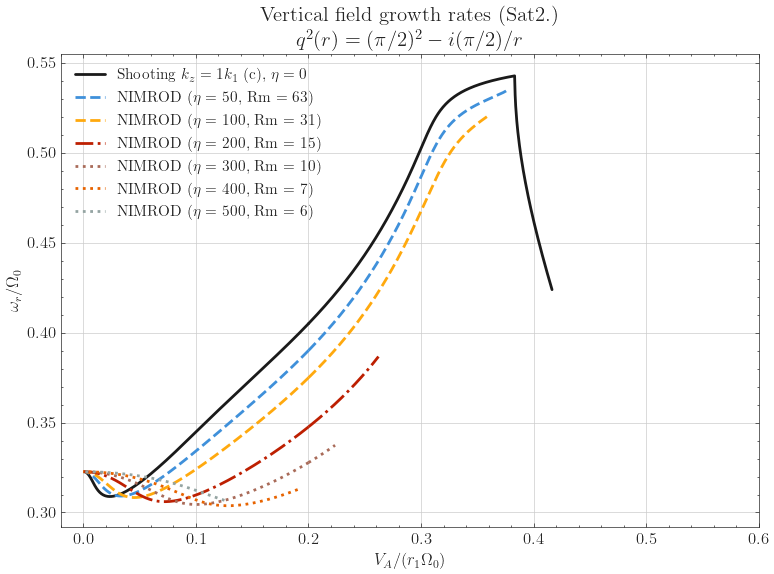

In [19]:
fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']



### RESISTIVE SHOOTING DATA

# plt.plot(VA_l_MCI1_Bz_ETA2_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA2_divr_WKB_div4, 'k', linestyle = '--', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 5$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA2_divr_WKB_div4,gr_1k1_MCI_h_Bz_ETA2_divr_WKB_div4, 'k', linestyle = '--', linewidth=2)    
V0 = r1*Omega0
eta = [50, 100, 200, 300, 400, 500]
Rm = r1*V0/np.array(eta)


plt.plot(VA_l_MCI1_Bz_qprofs2,freq_1k1_MCI_l_Bz_qprofs2, color = 'k', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 0$', linewidth=2)
plt.plot(VA_h_MCI1_Bz_qprofs2[0:450],freq_1k1_MCI_h_Bz_qprofs2[0:450], color = 'k', linewidth=2)    

i = 0
plt.plot(VA_l_MCI1_Bz_ETA50_divr_WKB_div4,freq_1k1_MCI_l_Bz_ETA50_divr_WKB_div4, color = color_arr[0], linestyle = '--', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA50_divr_WKB_div4[0:370],freq_1k1_MCI_h_Bz_ETA50_divr_WKB_div4[0:370], color = color_arr[0], linestyle = '--', linewidth=2)    


i = 1
plt.plot(VA_l_MCI1_Bz_ETA100_divr_WKB_div4,freq_1k1_MCI_l_Bz_ETA100_divr_WKB_div4, color = color_arr[1], linestyle = '--', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA100_divr_WKB_div4[0:330],freq_1k1_MCI_h_Bz_ETA100_divr_WKB_div4[0:330], color = color_arr[1], linestyle = '--', linewidth=2)    

i = 2
plt.plot(VA_l_MCI1_Bz_ETA200_divr_WKB_div4,freq_1k1_MCI_l_Bz_ETA200_divr_WKB_div4, color = color_arr[2], linestyle = '-.', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA200_divr_WKB_div4[0:130],freq_1k1_MCI_h_Bz_ETA200_divr_WKB_div4[0:130], color = color_arr[2], linestyle = '-.', linewidth=2)    
i = 3
plt.plot(VA_l_MCI1_Bz_ETA300_divr_WKB_div4,freq_1k1_MCI_l_Bz_ETA300_divr_WKB_div4, color = color_arr[5],linestyle = ':', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA300_divr_WKB_div4[0:50],freq_1k1_MCI_h_Bz_ETA300_divr_WKB_div4[0:50], color = color_arr[5],linestyle = ':', linewidth=2)    
i = 4
plt.plot(VA_l_MCI1_Bz_ETA400_divr_WKB_div4[20:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)],freq_1k1_MCI_l_Bz_ETA400_divr_WKB_div4[20:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)], color = color_arr[6],linestyle = ':', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA400_divr_WKB_div4[0:0],freq_1k1_MCI_h_Bz_ETA400_divr_WKB_div4[0:0], color = color_arr[6],linestyle = ':', linewidth=2)    

i = 5
plt.plot(VA_l_MCI1_Bz_ETA500_divr_WKB_div4[155:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)],freq_1k1_MCI_l_Bz_ETA500_divr_WKB_div4[155:len(VA_l_MCI1_Bz_ETA500_divr_WKB_div4)], color = color_arr[3],linestyle = ':', label=r'NIMROD ($\eta = $ ' + str(eta[i]) + ', Rm = ' + str(int(Rm[i])) + ')', linewidth=2)
plt.plot(VA_h_MCI1_Bz_ETA500_divr_WKB_div4[0:0],freq_1k1_MCI_h_Bz_ETA500_divr_WKB_div4[0:0], color = color_arr[3],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA600_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA600_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 600$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA600_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA600_divr_WKB_div4[0:0], color = color_arr[4],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA700_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA700_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 700$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA700_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA700_divr_WKB_div4[0:0], color = color_arr[4],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA800_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA800_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 800$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA800_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA800_divr_WKB_div4[0:0], color = color_arr[4],linestyle = ':', linewidth=2)    

# plt.plot(VA_l_MCI1_Bz_ETA1000_divr_WKB_div4,gr_1k1_MCI_l_Bz_ETA1000_divr_WKB_div4, color = color_arr[4],linestyle = ':', label =f'Shooting $k_z = 1k_1$ (c), $\eta = 1000$', linewidth=2)
# plt.plot(VA_h_MCI1_Bz_ETA1000_divr_WKB_div4[0:0],gr_1k1_MCI_h_Bz_ETA1000_divr_WKB_div4[0:0],color = color_arr[4], linestyle = ':', linewidth=2)    



plt.xlabel('$V_A/(r_1 \Omega_0)$',fontsize=12)
plt.ylabel(r'$\omega_r/\Omega_0$',fontsize=12)
plt.title('Vertical field growth rates (Sat2.)\n' + r'$q^2(r) = (\pi/2)^2 - i(\pi/2)/r$',fontsize=15)
# plt.axhline(y=0, linestyle = 'dashed')
# plt.xlim(0,0.7)
# plt.ylim(0,0.25)


# plt.text(1.3-0.05-.8, 0.25, '(a)', fontsize=20, color = color_arr[5], fontweight="bold")


# plt.axvline(x=.2, linestyle = '--', color = color_arr[6], linewidth=3)
# plt.text(1.05-.8, 0.3, 'MCI', fontsize=20, color = color_arr[6], fontweight="bold")
# plt.text(-0.03, 0.3, 'MRI', fontsize=20, color = color_arr[6], fontweight="bold")


box = ax.get_position()
# ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend()
# plt.ylim(0,0.02)
# plt.xlim(0,0.1)
plt.xlim(-0.02,0.6)
# plt.xlim(0,0.1)
# plt.legend()
# plt.
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('Shooting-NIMROD-comp/FreqvsAlfvenSpeed-NIMROD-Bz-WKB-Sat2.png', bbox_inches='tight')
plt.show()
plt.close()

# Scan

In [20]:
dt = 5
eta_arr = np.arange(5, 200, 5)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1'] ### ad 10k1 when done
diff_modes = ['MRI_1k1']
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_1k1', 'MRI_2k1']
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done
# diff_modes = ['MCI_1k1', 'MRI_6k1'] ### ad 10k1 when done

for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    if(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(5, 95, 5)
    else:
        eta_arr = np.arange(5, 200, 5)
        
    for j in eta_arr:
        # print(j)
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
    
        # gr_tot = np.concat((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[100:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)], gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # # print(len(VA_d))
        # # print(len(VA_u))
        # VA_N_total = np.concat((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[100:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)], VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        # gr_tot = np.concat(((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]), gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # VA_N_total = np.concat(((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]), VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        # print(len(gr_tot))
        
        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(5, 200, 5)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))

print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(len(e[k][j]))
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

(1602, 39, 4)


[[0.03502898 0.03503007 0.03502766 ... 0.03500089 0.03500093 0.03500098]
 [0.0352385  0.03518599 0.03514668 ... 0.03500231 0.03500221 0.03500213]
 [0.03584772 0.03564368 0.0354982  ... 0.03500656 0.03500606 0.03500561]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
(array([  0,   0,   0, ..., 794, 794, 795], dtype=int64), array([0, 1, 2, ..., 1, 2, 0], dtype=int64))


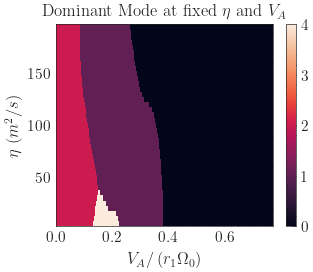

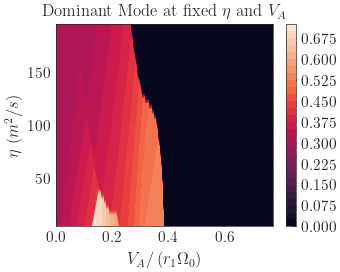

[0.1495308  0.0747654  0.0498436  0.0373827  0.02990616 0.0249218
 0.02136154 0.01869135 0.01661453 0.01495308 0.01359371 0.0124609
 0.01150237 0.01068077 0.00996872 0.00934567 0.00879593 0.00830727
 0.00787004 0.00747654 0.00712051 0.00679685 0.00650134 0.00623045
 0.00598123 0.00575118 0.00553818 0.00534039 0.00515623 0.00498436
 0.00482357 0.00467284 0.00453124 0.00439796 0.00427231 0.00415363
 0.00404137 0.00393502 0.00383412]


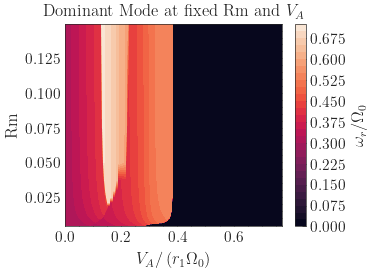

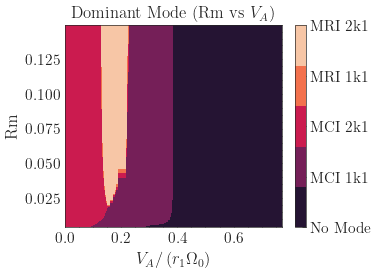

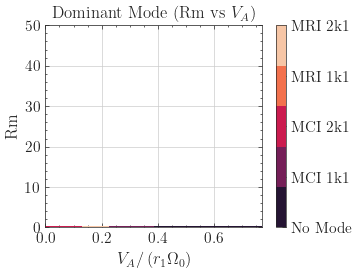

In [21]:

e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0



### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((len(gr_tot), len(eta_arr)))
gr_ijk_ii = np.zeros((len(gr_tot), len(eta_arr)))
freq_ijk = np.zeros((len(gr_tot), len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                
            
# gr_ii = np.where(gr_ijk <= 0)
# gr_ijk[gr_ii[:]] = 0
print(gr_ijk)
print(np.where(gr_ijk!=0))
fig = plt.figure()
# plt.contourf(VA_N_total, eta_arr, np.transpose((gr_ijk_ii)), 3)
plt.pcolormesh(VA_N_total, eta_arr, np.transpose((gr_ijk_ii)))

plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.colorbar()
plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
plt.show()

fig = plt.figure()
plt.contourf(VA_N_total, eta_arr, np.transpose((freq_ijk)),30)
# plt.contourf(VA_N_total, eta_arr, np.transpose((f11[:,:,0])), 30)

plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.colorbar()
plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
plt.show()


# r1 = 0.1 # cm to m
# V0 = r1*Omega0
# Rm = r1*V0/eta_arr

r1 = 7.06/100 # cm to m
Omega0_Sat2 = 150 ##rpm -> s
# print(Omega0_Sat2)
V0_Sat2 = r1*Omega0_Sat2
# print(V0_Sat2)
Rm = r1*V0_Sat2/eta_arr
print(Rm)

fig = plt.figure()
plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),30)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.show()

fig = plt.figure()
# contour = plt.contourf(VA_N_total, Rm, np.transpose((gr_ijk_ii)),3)
# contour = plt.pcolormesh(VA_N_total, Rm, np.transpose((gr_ijk_ii)))
contour = plt.contourf(VA_N_total, Rm, np.transpose((gr_ijk_ii)), 5)

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar(contour,  ticks=[0, 1, 2, 3, 4])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MRI $2k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
cbar.ax.set_yticklabels(['No Mode', 'MCI 1k1', 'MCI 2k1', 'MRI 1k1', 'MRI 2k1' ])

# Add a label to the colorbar
plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.show()


##############################################################################################
fig = plt.figure()
# contour = plt.contourf(VA_N_total, Rm, np.transpose((gr_ijk_ii)),3)
# contour = plt.pcolormesh(VA_N_total, Rm, np.transpose((gr_ijk_ii)))
contour = plt.contourf(VA_N_total, Rm, np.transpose((gr_ijk_ii)), 5)

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar(contour,  ticks=[0, 1, 2, 3, 4])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MRI $2k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
cbar.ax.set_yticklabels(['No Mode', 'MCI 1k1', 'MCI 2k1', 'MRI 1k1', 'MRI 2k1' ])

# Add a label to the colorbar
plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.ylim(0,50)
plt.show()

# Sat2 Scan MCI 1k1

## Import

In [22]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 5
eta_arr = np.arange(dt, 250 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done

diff_modes = ['m=0_1k1', 'm=0_2k1', 'MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1', 'm=0_2k1', 'm=0_3k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['m=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    # if(diff_modes[k] ==  'MCI_1k1'):
    #     eta_arr = np.arange(dt, 100 + dt, dt)
    # if(diff_modes[k] ==  'MCI_2k1'):
    #     eta_arr = np.arange(dt, 40 + dt, dt)
    # if(diff_modes[k] ==  'MCI_3k1'):
    #     eta_arr = np.arange(dt, 175 + dt, dt)
    if(diff_modes[k] ==  'MRI_4k1'):
        eta_arr = np.arange(dt, 55 + dt, dt)
    elif(diff_modes[k] ==  'MRI_6k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_8k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_10k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_1k1'):
    #     eta_arr = np.arange(1, 38 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_2k1'):
    #     eta_arr = np.arange(1, 128 + dt, dt)
    elif(diff_modes[k] ==  'm=0_3k1'):
        eta_arr = np.arange(5, 115 + dt, dt)
    else:
        eta_arr = np.arange(dt, 250 + dt, dt)

    for l in eta_arr:
        # print(eta_arr)
        # print(l)
        elecd_str = f'{l}'

        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        ### WKB 1k1 weird....
        if(k == 0):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        elif(k == 1):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        else:
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])

        # print(len(e12))
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        # print(len(e12))
        # print(len(gr_tot))
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 250 + dt, dt)


e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))


# e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
# f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))

print(np.shape(e11))

# print(len(d))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(e[k][j])
        # print(k)
        # print(j)
        # # print(len(e[k][j]))
        # print(len(e[k][j]))
        # print(k)
        # print(j)
        
        if(diff_modes[k] == 'm=0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
    
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250]
1
1
(1602, 50, 1)
(1602, 50, 1)


## Scan Freq

Gr = 0.01857696031459291


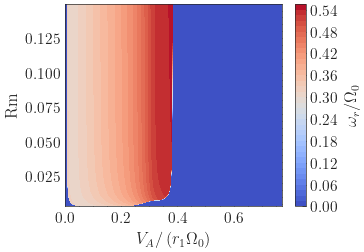

In [23]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

Gr0 = e11[0,0,0]
Gr0 = 0.01857696031459291
print(f'Gr = {Gr0}')

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            e11[i,j,k] = e11[i,j,k] - Gr0 
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k] 
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)


# print(np.where(gr_ijk_ii == 2))
### RM 

r1 = 7.06/100 # cm to m
Omega0_Sat2 = 150 ##rpm -> s
# print(Omega0_Sat2)
V0_Sat2 = r1*Omega0_Sat2
# print(V0_Sat2)
Rm = r1*V0_Sat2/eta_arr

fig = plt.figure()

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
plt.show()

## Scan GR

1
[0. 1.]


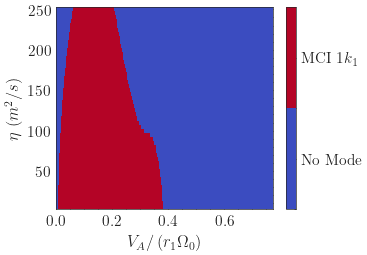

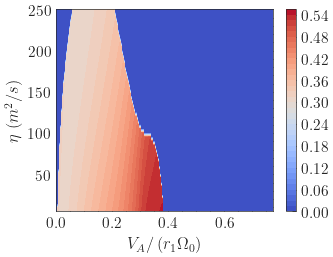

In [24]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

## Rm

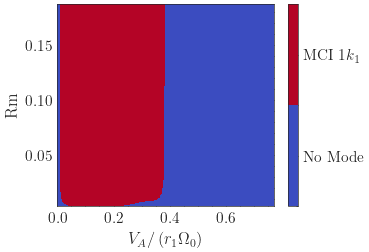

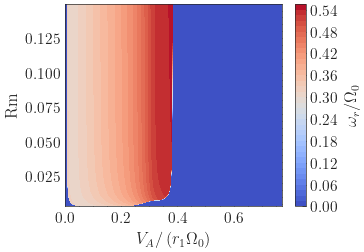

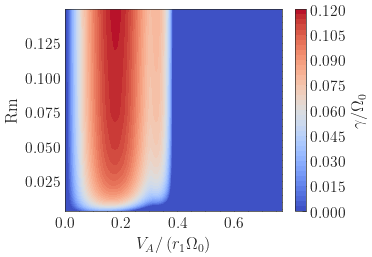

In [25]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig = plt.figure()
levels = [0,1,2]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.savefig('Rm-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.ylim(np.min(Rm), 250)
# plt.savefig('Rm-vA-Sat2-dommode-freq.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2]

gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


# plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)

plt.show()

# Sat2 Scan qmagpi

## Import

In [26]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 5
eta_arr = np.arange(dt, 500 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done

diff_modes = ['m=0_1k1', 'm=0_2k1', 'MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1', 'm=0_2k1', 'm=0_3k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done
# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['m=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    # if(diff_modes[k] ==  'MCI_1k1'):
    #     eta_arr = np.arange(dt, 100 + dt, dt)
    # if(diff_modes[k] ==  'MCI_2k1'):
    #     eta_arr = np.arange(dt, 40 + dt, dt)
    # if(diff_modes[k] ==  'MCI_3k1'):
    #     eta_arr = np.arange(dt, 175 + dt, dt)
    if(diff_modes[k] ==  'MRI_4k1'):
        eta_arr = np.arange(dt, 55 + dt, dt)
    elif(diff_modes[k] ==  'MCI_1k1'):
        eta_arr = np.arange(dt, 500 + dt, dt)
    elif(diff_modes[k] ==  'MRI_6k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_8k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_10k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_1k1'):
    #     eta_arr = np.arange(1, 38 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_2k1'):
    #     eta_arr = np.arange(1, 128 + dt, dt)
    elif(diff_modes[k] ==  'm=0_3k1'):
        eta_arr = np.arange(5, 115 + dt, dt)
    else:
        eta_arr = np.arange(dt, 250 + dt, dt)

    for l in eta_arr:
        # print(eta_arr)
        # print(l)
        elecd_str = f'{l}'

        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        ### WKB 1k1 weird....
        # if(k == 0):
        #     guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        #     guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        #     VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        #     VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        # elif(k == 1):
        #     guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        #     guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        #     VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        #     VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        # else:
        #     guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        #     guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        #     VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        #     VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])

        # print(len(e12))
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        # print(len(e12))
        # print(len(gr_tot))
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 500 + dt, dt)


e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))


# e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
# f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))

print(np.shape(e11))

# print(len(d))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(e[k][j])
        # print(k)
        # print(j)
        # # print(len(e[k][j]))
        # print(len(e[k][j]))
        # print(k)
        # print(j)
        
        if(diff_modes[k] == 'm=0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
    
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]
        

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265 270
 275 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355 360
 365 370 375 380 385 390 395 400 405 410 415 420 425 430 435 440 445 450
 455 460 465 470 475 480 485 490 495 500]
7
7
(1602, 100, 7)
(1602, 100, 7)


## Freq

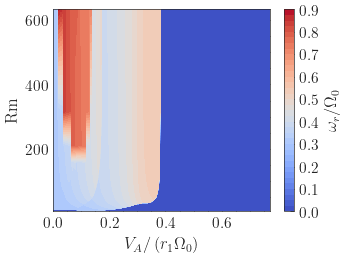

In [27]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

# Gr0 = e11[0,0,0]
# # Gr0 = 0.01857696031459291
# print(f'Gr = {Gr0}')

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            e11[i,j,k] = e11[i,j,k] - Gr0 
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k] 
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)


Rm = 0.1**2*Omega0/eta_arr
fig = plt.figure()

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
plt.show()

## GR

7
[0. 1. 2. 3. 4. 5. 6. 7.]


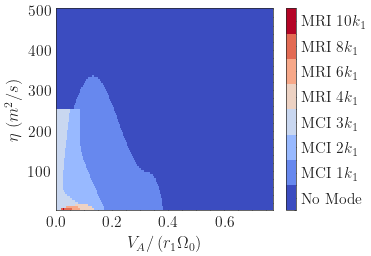

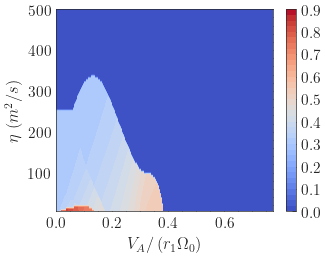

In [28]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

## GR - Eta - Offset

7
[0. 1. 2. 3. 4. 5. 6. 7.]


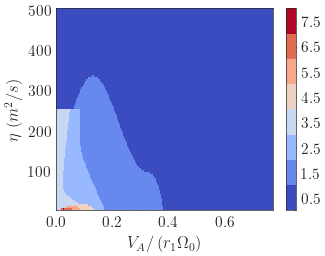

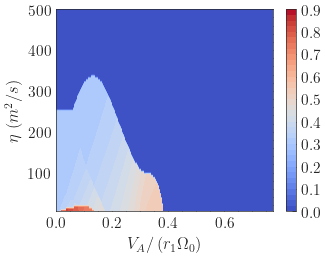

In [29]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

## GR - RM

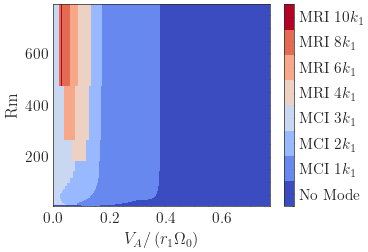

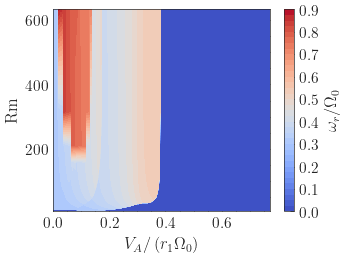

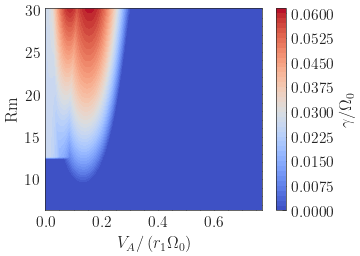

In [30]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.savefig('Rm-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

# ################ Zoom
# fig = plt.figure()
# levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # Add a colorbar


# tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
# cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# # Add a label to the colorbar
# # plt.title(r'Dominant Mode (Rm vs $V_A$)')
# # plt.legend()
# plt.ylim(np.min(Rm), 250)
# # plt.ylim(0, 250)
# plt.axvline(x = VAm, linestyle = '--', color = 'w')
# # plt.axhline(y = Rmm, linestyle = '--', color = 'k')
# # plt.plot(VAm, Rmm, 'o', color = 'k')
# plt.axhline(y = Rmm, linestyle = '--', color = 'w')
# plt.plot(VAm, Rmm, 'o', color = 'w')
# plt.text(0.2, 50, f'Rm = {np.round(Rmm,1)}', fontsize=12, color = 'w', fontweight = 'heavy')
# plt.text(0.2, 50, r'$\mathrm{Rm}^{min}= $' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(0.15, 50, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(0.2, 50, r'min(Rm) =' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')

# plt.axhline(y = Rmm, linestyle = '--')
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.ylim(np.min(Rm), 250)
plt.savefig('Rm-vA-Sat2-dommode-freq.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8]

gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm[20:len(Rm)], np.transpose(gr_ijk)[20:len(Rm), :], cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.ylim(np.min(Rm), 50)
# Add a colorbar


# plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)

plt.show()

# Sat2 - m=0

In [71]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 5
eta_arr = np.arange(dt, 250 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done

diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1', 'm=0_2k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done
# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['m=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    # if(diff_modes[k] ==  'MCI_1k1'):
    #     eta_arr = np.arange(dt, 100 + dt, dt)
    # if(diff_modes[k] ==  'MCI_2k1'):
    #     eta_arr = np.arange(dt, 40 + dt, dt)
    # if(diff_modes[k] ==  'MCI_3k1'):
    #     eta_arr = np.arange(dt, 175 + dt, dt)
    if(diff_modes[k] ==  'MRI_4k1'):
        eta_arr = np.arange(dt, 55 + dt, dt)
    elif(diff_modes[k] ==  'MRI_6k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_8k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_10k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'm=0_1k1'):
        eta_arr = np.arange(dt, 140 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_2k1'):
    #     eta_arr = np.arange(1, 128 + dt, dt)
    elif(diff_modes[k] ==  'm=0_3k1'):
        eta_arr = np.arange(5, 115 + dt, dt)
    else:
        eta_arr = np.arange(dt, 250 + dt, dt)

    for l in eta_arr:
        # print(eta_arr)
        # print(l)
        elecd_str = f'{l}'

        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        ### WKB 1k1 weird....
        if(k == 0):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        elif(k == 1):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        else:
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])

        # print(len(e12))
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        # print(len(e12))
        # print(len(gr_tot))
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 250 + dt, dt)


e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))


# e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
# f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))

print(np.shape(e11))

# print(len(d))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(e[k][j])
        # print(k)
        # print(j)
        # # print(len(e[k][j]))
        # print(len(e[k][j]))
        # print(k)
        # print(j)
        
        if(diff_modes[k] == 'm=0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
    
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250]
9
9
(1602, 50, 9)
(1602, 50, 9)


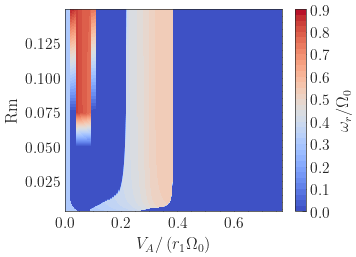

In [72]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0



### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
                
# print(np.where(gr_ijk_ii == 2))
### RM 

r1 = 7.06/100 # cm to m
Omega0_Sat2 = 150 ##rpm -> s
# print(Omega0_Sat2)
V0_Sat2 = r1*Omega0_Sat2
# print(V0_Sat2)
Rm = r1*V0_Sat2/eta_arr

fig = plt.figure()

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
plt.show()

9
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


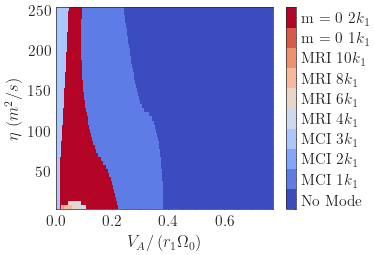

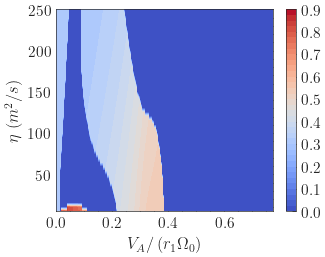

In [73]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8,9,10]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$', r'm = 0 $2k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$'])

# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

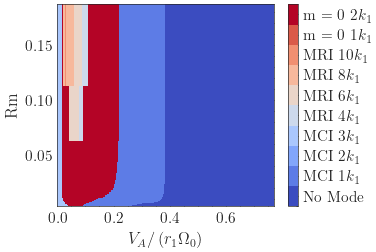

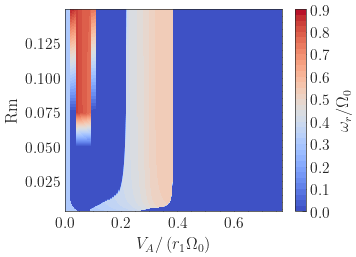

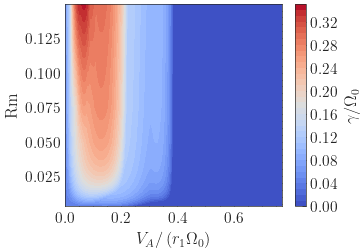

In [74]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]
cmap = 'coolwarm'
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7,8,9])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$', r'm = 0 $2k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.savefig('Rm-vA-Sat2-dommode-qmagpi-m0.png', dpi = 400)
plt.show()

# ################ Zoom
# fig = plt.figure()
# levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # Add a colorbar


# tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
# cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# # Add a label to the colorbar
# # plt.title(r'Dominant Mode (Rm vs $V_A$)')
# # plt.legend()
# plt.ylim(np.min(Rm), 250)
# # plt.ylim(0, 250)
# plt.axvline(x = VAm, linestyle = '--', color = 'w')
# # plt.axhline(y = Rmm, linestyle = '--', color = 'k')
# # plt.plot(VAm, Rmm, 'o', color = 'k')
# plt.axhline(y = Rmm, linestyle = '--', color = 'w')
# plt.plot(VAm, Rmm, 'o', color = 'w')
# plt.text(0.2, 50, f'Rm = {np.round(Rmm,1)}', fontsize=12, color = 'w', fontweight = 'heavy')
# plt.text(0.2, 50, r'$\mathrm{Rm}^{min}= $' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(0.15, 50, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(0.2, 50, r'min(Rm) =' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')

# plt.axhline(y = Rmm, linestyle = '--')
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7,8,9])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.ylim(np.min(Rm), 250)
plt.savefig('Rm-vA-Sat2-dommode-freq-m0.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]

gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


# plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)

plt.show()

# Sat2. Exp. Rm Scan

In [35]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 5
# eta_arr = np.arange(dt, 250 + dt, dt)
ETA = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.125,0.15,0.175,0.2,0.275,0.35,0.425,0.5]

r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done

diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1', 'm=0_2k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done
# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['m=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []

        # eta_arr = np.arange(dt, 250 + dt, dt)
    eta_arr = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.125,0.15,0.175,0.2,0.275,0.35,0.425,0.5]


    for l in eta_arr:
        # print(eta_arr)
        # print(l)
        elecd_str = f'{l}'

        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        ### WKB 1k1 weird....
        if(k == 0):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        elif(k == 1):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'
        else:
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])

        # print(len(e12))
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        # print(len(e12))
        # print(len(gr_tot))
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.125,0.15,0.175,0.2,0.275,0.35,0.425,0.5]


e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))


# e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
# f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))

print(np.shape(e11))

# print(len(d))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(e[k][j])
        # print(k)
        # print(j)
        # # print(len(e[k][j]))
        # print(len(e[k][j]))
        # print(k)
        # print(j)
        
        if(diff_modes[k] == 'm=0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
    
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250]
9
9


FileNotFoundError: [Errno 2] No such file or directory: 'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_0.01-kep-Bz-res-divr-WKB-div2-Sat2-PM0.pkl'

# Tanh Scan

## Conv on Hyd.

316227.7660168379
7
0
100
200
300
400
500
600


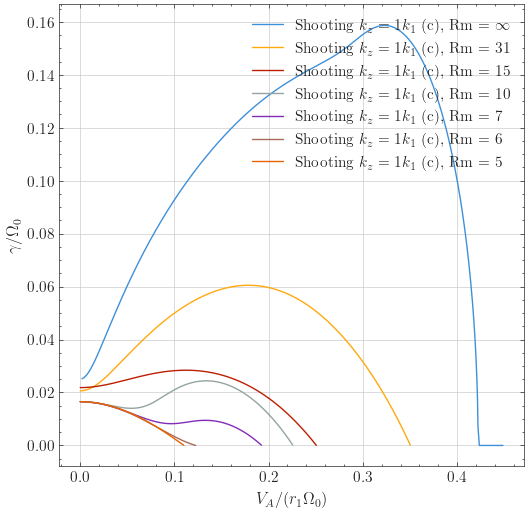

In [598]:
dt = 100
r1 = 0.1
print(Omega0)
eta_arr = np.arange(0, 700, dt)
print(len(eta_arr))
e = []
f1 = []
diff_modes = ['MCI_1k1'] ### ad 10k1 when done
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']
n = 0
fig = plt.figure(figsize=(6,6))

for k in range(0,len(diff_modes)):
    for l in eta_arr:
        if(l != 0):
            elecd_str = f'{l}'
        
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        else:
            elecd_str = f'{l}'
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-Tanhv2-Bz.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-Tanhv2-Bz.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-Tanhv2-Bz.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-Tanhv2-Bz.pkl'
    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = np.array(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4)
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = np.array(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)
        VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = np.array(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)
        # ii = np.where(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 < 0)
        # gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] = 0
        # ii = np.where(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 < 0)
        # gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[ii[:]] = 0

        ii = np.where(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 > 0)
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[ii[:]] 
        VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = VA_l_MCI1_Bz_ETA1_divr_WKB_div4[ii[:]] 
        ii = np.where(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 > 0)
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4= gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] 
        VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[ii[:]] 
        
        print(l)
        if(l != 0):
            plt.plot(VA_l_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4, color= color_arr[n], label = r'Shooting $k_z = 1k_1$ (c), ' + f'Rm = {int(r1**2*Omega0/l)}')
        else:
            plt.plot(VA_l_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4, color= color_arr[n], label = r'Shooting $k_z = 1k_1$ (c), ' + r'Rm = $\infty$')

        plt.plot(VA_h_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4, color= color_arr[n])
        plt.xlabel(r'$V_A/(r_1\Omega_0)$')
        plt.ylabel(r'$\gamma/\Omega_0$')
        # plt.ylim()
        n = n + 1
plt.legend(loc= 'upper right')
plt.savefig('Shooting-prof-sat2/Tanh2-Hydmode-Conv.png', dpi = 400)
plt.savefig('Shooting-prof-sat2/Tanh2-Hydmode-Conv.svg', format = 'svg')

plt.show()

In [599]:
dt = 100
r1 = 0.1
print(Omega0)
eta_arr = np.arange(0, 700, dt)
print(len(eta_arr))
e = []
f1 = []
diff_modes = ['MCI_2k1'] ### ad 10k1 when done
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']
n = 0
fig = plt.figure(figsize=(6,6))

for k in range(0,len(diff_modes)):
    for l in eta_arr:
        # if(l != 0):
        #     elecd_str = f'{l}'
        
        #     guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        #     guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        #     VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        #     VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        # else:
        #     elecd_str = f'{l}'
        #     guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-Tanhv2-Bz.pkl'
        #     guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-Tanhv2-Bz.pkl'
        #     VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-Tanhv2-Bz.pkl'
        #     VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-Tanhv2-Bz.pkl'
            
        elecd_str = f'{l}'
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str +  '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str +  '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = np.array(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4)
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = np.array(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4)
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = np.array(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)
        VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = np.array(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)
        # ii = np.where(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 < 0)
        # gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] = 0
        # ii = np.where(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 < 0)
        # gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[ii[:]] = 0

        ii = np.where(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 > 0)
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[ii[:]] 
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[ii[:]] 
        VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = VA_l_MCI1_Bz_ETA1_divr_WKB_div4[ii[:]] 
        ii = np.where(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 > 0)
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4= gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] 
        VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[ii[:]] 
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] 
        print(l)
        if(l != 0):
            plt.plot(VA_l_MCI1_Bz_ETA1_divr_WKB_div4, freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4, color= color_arr[n], label = r'Shooting $k_z = 1k_1$ (c), ' + f'Rm = {int(r1**2*Omega0/l)}')
        else:
            plt.plot(VA_l_MCI1_Bz_ETA1_divr_WKB_div4, freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4, color= color_arr[n], label = r'Shooting $k_z = 1k_1$ (c), ' + r'Rm = $\infty$')

        plt.plot(VA_h_MCI1_Bz_ETA1_divr_WKB_div4, freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4, color= color_arr[n])
        plt.xlabel(r'$V_A/(r_1\Omega_0)$')
        plt.ylabel(r'$\omega_r/\Omega_0$')
        # plt.ylim()
        n = n + 1
plt.legend(loc= 'upper right')
plt.savefig('Shooting-prof-sat2/Tanh2-Hydmode-Conv-freq.png', dpi = 400)
plt.savefig('Shooting-prof-sat2/Tanh2-Hydmode-Conv-freq.svg', format = 'svg')

plt.show()

316227.7660168379
7


FileNotFoundError: [Errno 2] No such file or directory: 'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_guessesd_0-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'

<Figure size 600x600 with 0 Axes>

## Rest

In [603]:
dt = 5
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1'] ### ad 10k1 when done
diff_modes = ['MRI_1k1']
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_1k1', 'MRI_2k1']
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] 
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done
# diff_modes = ['MCI_1k1', 'MRI_6k1'] ### ad 10k1 when done

for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    # if(diff_modes[k] == 'MRI_8k1'):
    #     eta_arr = np.arange(5, 95, 5)
    # elif(diff_modes[k] == 'MRI_10k1'):
    #     eta_arr = np.arange(5, 75, 5)
    # else:
    #     eta_arr = np.arange(dt, 200, dt)

    if(diff_modes[k] == 'MRI_8k1'):
        eta_arr = np.arange(5, 70, 5)
    elif(diff_modes[k] == 'MRI_10k1'):
        eta_arr = np.arange(5, 50, 5)
    else:
        eta_arr = np.arange(dt, 200, dt)
        
    for j in eta_arr:
        # print(j)
        elecd_str = f'{j}'
    
        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'

    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
    
        # gr_tot = np.concat((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[100:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)], gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # # print(len(VA_d))
        # # print(len(VA_u))
        # VA_N_total = np.concat((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[100:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)], VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        # gr_tot = np.concat(((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]), gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # VA_N_total = np.concat(((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]), VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        # print(len(gr_tot))
        
        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(5, 200, 5)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))

print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(len(e[k][j]))
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

(1602, 39, 7)


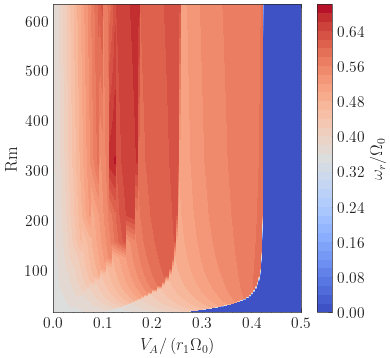

In [604]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0



### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
                
# print(np.where(gr_ijk_ii == 2))
### RM 


Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)


plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.xlim(0,0.5)
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
plt.show()

7
[0. 1. 2. 3. 4. 5. 6. 7.]


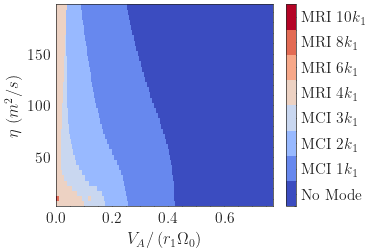

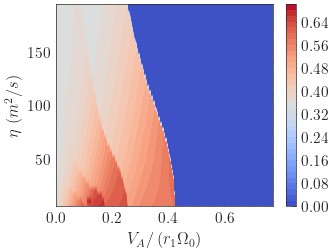

In [605]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$'])

# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

In [606]:

# ### Coolwarm good cmap
# # Spectral OK
# # RdGy OK
# fig = plt.figure()
# levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # Add a colorbar


# tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
# cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# # Add a label to the colorbar
# # plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Tanh-dommode-qmagpi.png', dpi = 400)
# plt.show()

# # ################ Zoom
# # fig = plt.figure()
# # levels = [0,1,2,3,4,5,6,7,8]

# # contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# # plt.ylabel(r'Rm')
# # plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # # Add a colorbar


# # tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
# # cbar = plt.colorbar(contour,  ticks=tickss) 
# # cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# # # Add a label to the colorbar
# # # plt.title(r'Dominant Mode (Rm vs $V_A$)')
# # # plt.legend()
# # plt.ylim(np.min(Rm), 250)
# # # plt.ylim(0, 250)
# # plt.axvline(x = VAm, linestyle = '--', color = 'w')
# # # plt.axhline(y = Rmm, linestyle = '--', color = 'k')
# # # plt.plot(VAm, Rmm, 'o', color = 'k')
# # plt.axhline(y = Rmm, linestyle = '--', color = 'w')
# # plt.plot(VAm, Rmm, 'o', color = 'w')
# # plt.text(0.2, 50, f'Rm = {np.round(Rmm,1)}', fontsize=12, color = 'w', fontweight = 'heavy')
# # plt.text(0.2, 50, r'$\mathrm{Rm}^{min}= $' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')
# # plt.text(0.15, 50, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# # plt.text(0.2, 50, r'min(Rm) =' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')

# # plt.axhline(y = Rmm, linestyle = '--')
# # plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.png', dpi = 400)
# plt.show()

# ################ Zoom
# fig = plt.figure()
# levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),10, cmap ='coolwarm')

# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # Add a colorbar


# tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
# cbar = plt.colorbar(contour) 
# cbar.set_label(r'$\omega_r/\Omega_0$')
# # cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# # Add a label to the colorbar
# # plt.title(r'Dominant Mode (Rm vs $V_A$)')
# # plt.legend()
# # plt.ylim(np.min(Rm), 250)
# plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Tanh-dommode-freq.png', dpi = 400)
# plt.show()

# ################ Zoom
# fig = plt.figure()
# levels = [0,1,2,3,4,5,6,7,8]

# gr_ijk_log = np.zeros(np.shape(gr_ijk))
# gr_ijk_jj = np.where(gr_ijk != 0)
# gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
# contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
# cbar = plt.colorbar()
# cbar.set_label(r'$\gamma/\Omega_0$')

# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # Add a colorbar

# plt.xlim(0,0.5)
# # plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)

# plt.show()

### Plot Specifics

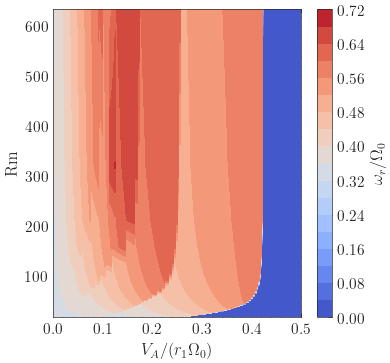

In [607]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)


# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm,zorder=-20 )
contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)), 20, cmap=cmap)
# plt.ylim(np.min(Rm),np.max(Rm))
# ax2.set_rasterization_zorder(-10)
# ax2.grid(False)

cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.ylim(np.min(Rm), np.max(Rm) + 1000)

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)

plt.savefig('Rm-vA-Tanh-3r1-freq-qmagpi.png', dpi = 400)
plt.savefig('Rm-vA-Tanh-3r1-freq-qmagpi.svg', format = 'svg')
# plt.savefig('Rm-vA-Kep-freq-qmagpi.pdf')
plt.xlim(0, 0.5)
plt.show()

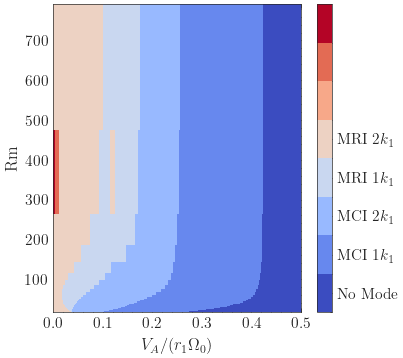

In [608]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm,zorder=-20 )
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# ax2.set_rasterization_zorder(-10)
# ax2.grid(False)

tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])




lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
# plt.ylim(np.min(Rm), 250)
plt.savefig('Rm-vA-Tanh-3r1-dommode-qmagpi-zoom.png', dpi = 400)
plt.savefig('Rm-vA-Tanh-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')
plt.xlim(0, 0.5)
plt.show()

In [609]:
#

## Hyd Offset

In [674]:
dt = 5
eta_arr = np.arange(dt, 1000, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1'] ### ad 10k1 when done
diff_modes = ['MRI_1k1']
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_1k1', 'MRI_2k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] 
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] 

# diff_modes = ['MCI_1k1'] ### ad 10k1 when done
# diff_modes = ['MCI_1k1', 'MRI_6k1'] ### ad 10k1 when done

for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    # if(diff_modes[k] == 'MRI_8k1'):
    #     eta_arr = np.arange(5, 95, 5)
    # elif(diff_modes[k] == 'MRI_10k1'):
    #     eta_arr = np.arange(5, 75, 5)
    # else:
    #     eta_arr = np.arange(dt, 200, dt)

    if(diff_modes[k] == 'MRI_8k1'):
        eta_arr = np.arange(5, 70, 5)
    elif(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(5,795, 5)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(5,320, 5)
    elif(diff_modes[k] == 'MCI_3k1'):
        eta_arr = np.arange(5,250, 5)
    elif(diff_modes[k] == 'MRI_4k1'):
        eta_arr = np.arange(5, 250, 5)
    elif(diff_modes[k] == 'MRI_6k1'):
        eta_arr = np.arange(5, 250, 5)
    elif(diff_modes[k] == 'MRI_10k1'):
        eta_arr = np.arange(5, 50, 5)
    else:
        eta_arr = np.arange(dt, 1000, dt)
        
    for j in eta_arr:
        # print(j)
        elecd_str = f'{j}'
    
        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'

    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
    
        # gr_tot = np.concat((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[100:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)], gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # # print(len(VA_d))
        # # print(len(VA_u))
        # VA_N_total = np.concat((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[100:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)], VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        # gr_tot = np.concat(((gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]), gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4))
        # VA_N_total = np.concat(((VA_l_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]), VA_h_MCI1_Bz_ETA1_divr_WKB_div4))
    
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        # print(len(gr_tot))
        
        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(5, 1000, 5)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))

print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(len(e[k][j]))
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

(1602, 199, 6)


316227.7660168379
600
(1602, 199)


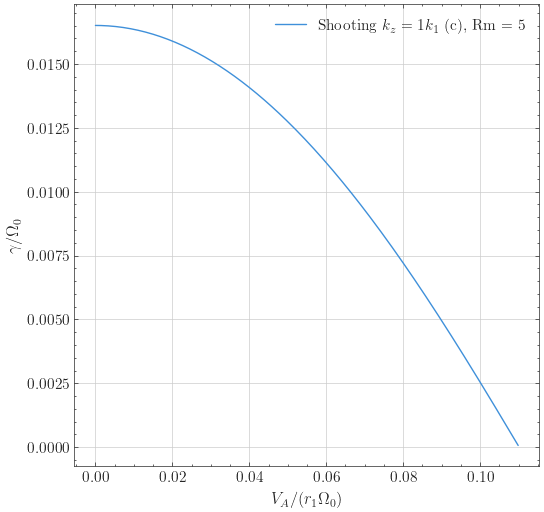

In [675]:
dt = 100
r1 = 0.1
print(Omega0)
eta_arr1 = [600]
e = []
f1 = []
diff_modes = ['MCI_1k1'] ### ad 10k1 when done
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']
n = 0
fig = plt.figure(figsize=(6,6))

for k in range(0,len(diff_modes)):
    for l in eta_arr1:
        if(l != 0):
            elecd_str = f'{l}'
        
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Tanhv2-PM0.pkl'
        else:
            elecd_str = f'{l}'
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesu_' + elecd_str + '-Tanhv2-Bz.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_guessesd_' + elecd_str + '-Tanhv2-Bz.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANUP_' + elecd_str + '-Tanhv2-Bz.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/MCI_1k1_VANDOWN_' + elecd_str + '-Tanhv2-Bz.pkl'
    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = np.array(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4)
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = np.array(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)
        VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = np.array(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)

        ii = np.where(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 > 0)
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[ii[:]] 
        VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = VA_l_MCI1_Bz_ETA1_divr_WKB_div4[ii[:]] 
        ii = np.where(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 > 0)
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4= gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] 
        VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[ii[:]] 
        
        print(l)
        if(l != 0):
            plt.plot(VA_l_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4, color= color_arr[n], label = r'Shooting $k_z = 1k_1$ (c), ' + f'Rm = {int(r1**2*Omega0/l)}')
        else:
            plt.plot(VA_l_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4, color= color_arr[n], label = r'Shooting $k_z = 1k_1$ (c), ' + r'Rm = $\infty$')

        plt.plot(VA_h_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4, color= color_arr[n])
        plt.xlabel(r'$V_A/(r_1\Omega_0)$')
        plt.ylabel(r'$\gamma/\Omega_0$')
        # plt.ylim()
        n = n + 1

        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) )
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) )
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total2 = VA12
        gr_tot2 = e12

        
plt.legend(loc= 'upper right')

# plt.plot(VA_N_total, e12)
# print(np.shape(VA_N_total)[0])
# print(np.shape(VA_N_total2))
# print(np.shape(e12))
# plt.show()

# print(np.shape(gr_ijk))
Hyd_offset_arr = np.zeros((np.shape(gr_ijk)))
# print('shape arra')
print(np.shape(Hyd_offset_arr))
for j in range(0,np.shape(Hyd_offset_arr)[1]):
    Hyd_offset_arr[0:len(VA_N_total2), j] = e12.imag[0:len(e12)]
Hyd_offset_arr = np.zeros((np.shape(gr_ijk)))


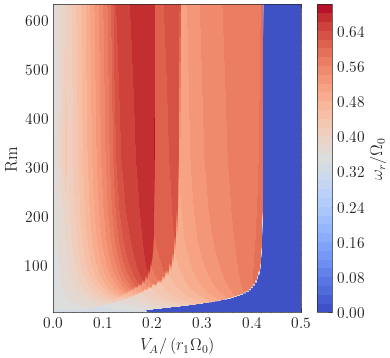

In [676]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] 


### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                if(k == 1):
                    gr_ijk[i,j] = Hyd_offset_arr[i,j]
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
                

# gr_ii = np.where(gr_ijk_ii == 1)
# gr_ijk_MCI1k1 = gr_ijk[gr_ii[:]]

# gr_ijk_MCI1k1 = gr_ijk[gr_ii[:]] - Hyd_offset_arr[gr_ii[:]] 


Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)


plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.xlim(0,0.5)
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
plt.show()

6
[0. 1. 2. 3. 4. 5. 6.]


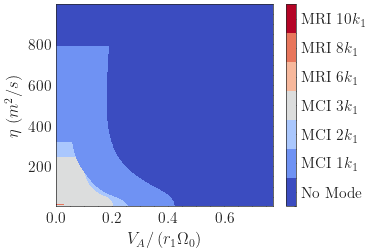

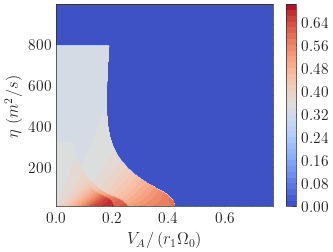

In [677]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8]
levels = [0,1,2,3,4,5,6,7]

# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$'])

# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

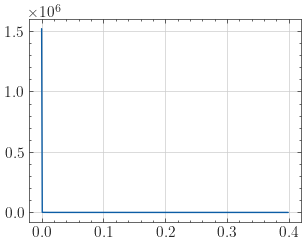

In [678]:
# RmH contour
r = np.arange(1,3, 1/100)
kz = 1*np.pi/2
## PLOT ALL
q_mag = 2*np.pi**2
q2r_sc = q_mag/r**2
q2rp_sc = -2*q_mag/r**3
q2i_sc = q_mag*np.zeros(len(r))
q2ip_sc = q_mag*np.zeros(len(r))

ones_arr = np.ones(len(r)) 
k2 = (q2r_sc + 1j*q2i_sc) + m**2/r**2 + kz**2 * ones_arr
k2p = ((q2rp_sc + 1j*q2ip_sc) - 2 * m**2/r**3) ## just changed from d/dr
k2r_f = i2.CubicSpline(r, k2.real)

vAN = np.arange(1E-6, 0.4, 1/1000)
wAN = kz*vAN
RmH = k2r_f(3)/(2*wAN)

plt.figure()
plt.plot(vAN, RmH)

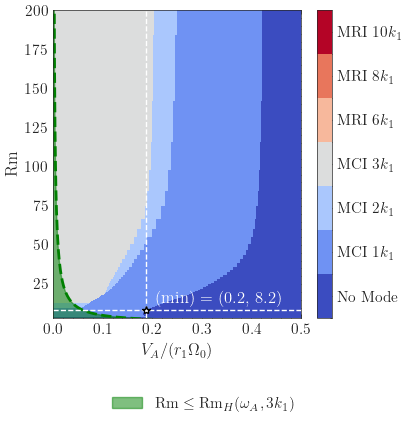

In [720]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

# levels = [0,1,2,3,4,5,6,7,8]
levels = [0,1,2,3,4,5,6,7]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm,zorder=-20 )
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# ax2.set_rasterization_zorder(-10)
# ax2.grid(False)

# tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
tickss = np.array([0,1,2,3,4,5,6])+ 0.5

cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$',r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])


# plt.plot(vAN, RmH, linestyle = 'dashed', color = color_arr[4], linewidth = 2)
# plt.fill_between(vAN, 0, RmH, color = color_arr[4], alpha=0.5, label = r'$\mathrm{Rm} \leq \mathrm{Rm}_{H}(\omega_A, 1k_1)$')

# plt.plot(vAN, 1/2*RmH, linestyle = 'dashed', color = color_arr[6], linewidth = 2)
# plt.fill_between(vAN, 0, 1/2*RmH, color = color_arr[6], alpha=0.5, label = r'$\mathrm{Rm} \leq \mathrm{Rm}_{H}(\omega_A, 2k_1)$')

plt.plot(vAN, 1/3*RmH, linestyle = 'dashed', color = 'green', linewidth = 2)
plt.fill_between(vAN, 0, 1/3*RmH, color = 'green', alpha=0.5, label = r'$\mathrm{Rm} \leq \mathrm{Rm}_{H}(\omega_A, 3k_1)$')


VAm = 0.1875 
Rmm = 8.15

plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.text(VAm + 0.02, Rmm+5, f'(min) = {(np.round(VAm,1), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')


lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, -0.2),  # Position the legend below the plot
           frameon=False,  # Turn on the frame (border)
           edgecolor='black',  # Set the border color
           facecolor='white',  # Set the background color of the legend box
           borderpad=1,  # Padding between the legend text and the border
           borderaxespad=1)
plt.ylim(np.min(Rm), 200)
plt.xlim(0, 0.5)

# plt.ylim(3,5)
# plt.xlim(0.18,0.2)
# plt.savefig('Rm-vA-Tanh-3r1-dommode-qmagpi-zoom.png', dpi = 400)
# plt.savefig('Rm-vA-Tanh-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')

plt.show()

<!-- # Tanh m = 0 -->

In [ ]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 5
eta_arr = np.arange(dt, 250 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done

diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1', 'm=0_2k1'] # ad 10k1 when done
# diff_modes = ['m=0_1k1', 'm=0_2k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done
# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['m=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    if(diff_modes[k] == 'MRI_8k1'):
        eta_arr = np.arange(5, 70, 5)
    elif(diff_modes[k] == 'MRI_10k1'):
        eta_arr = np.arange(5, 50, 5)
    else:
        eta_arr = np.arange(dt, 200, dt)
        
    # if(diff_modes[k] ==  'MCI_1k1'):
    #     eta_arr = np.arange(dt, 100 + dt, dt)
    # if(diff_modes[k] ==  'MCI_2k1'):
    #     eta_arr = np.arange(dt, 40 + dt, dt)
    # if(diff_modes[k] ==  'MCI_3k1'):
    #     eta_arr = np.arange(dt, 175 + dt, dt)
    # if(diff_modes[k] ==  'MRI_4k1'):
    #     eta_arr = np.arange(dt, 55 + dt, dt)
    # elif(diff_modes[k] ==  'MRI_6k1'):
    #     eta_arr = np.arange(dt, 25 + dt, dt)
    # elif(diff_modes[k] ==  'MRI_8k1'):
    #     eta_arr = np.arange(dt, 25 + dt, dt)
    # elif(diff_modes[k] ==  'MRI_10k1'):
    #     eta_arr = np.arange(dt, 25 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_1k1'):
    #     eta_arr = np.arange(dt, 140 + dt, dt)
    # # elif(diff_modes[k] ==  'm=0_2k1'):
    # #     eta_arr = np.arange(1, 128 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_3k1'):
    #     eta_arr = np.arange(5, 115 + dt, dt)
    # else:
    #     eta_arr = np.arange(dt, 250 + dt, dt)
    # eta_arr = np.arange(dt, 200 + dt, dt)

    for l in eta_arr:
        # print(eta_arr)
        # print(l)
        elecd_str = f'{l}'

        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        ### WKB 1k1 weird....
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Tanhv2-PM0.pkl'

        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])

        # print(len(e12))
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        # print(len(e12))
        # print(len(gr_tot))
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 200 + dt, dt)


e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))


# e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
# f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))

print(np.shape(e11))

# print(len(d))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(e[k][j])
        # print(k)
        # print(j)
        # # print(len(e[k][j]))
        # print(len(e[k][j]))
        # print(k)
        # print(j)
        
        if(diff_modes[k] == 'm=0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
    
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250]
9
9
(1602, 40, 9)
(1602, 40, 9)


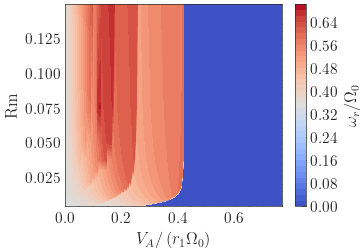

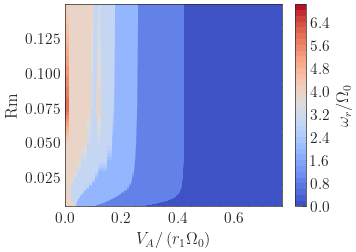

In [ ]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0



### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((len(e[0][0]), len(eta_arr)))
gr_ijk_ii = np.zeros((len(e[0][0]), len(eta_arr)))
freq_ijk = np.zeros((len(e[0][0]), len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
                
# print(np.where(gr_ijk_ii == 2))
### RM 

r1 = 7.06/100 # cm to m
Omega0_Sat2 = 150 ##rpm -> s
# print(Omega0_Sat2)
V0_Sat2 = r1*Omega0_Sat2
# print(V0_Sat2)
Rm = r1*V0_Sat2/eta_arr

fig = plt.figure()

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
plt.show()

plt.contourf(VA_N_total, Rm, np.transpose((gr_ijk_ii)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
plt.show()


9
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


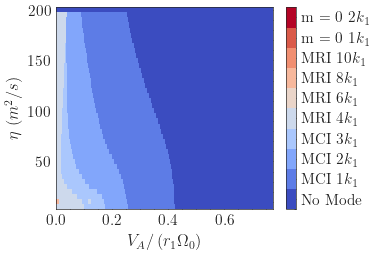

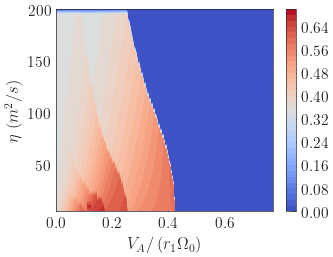

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8,9,10]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$', r'm = 0 $2k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$'])

# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

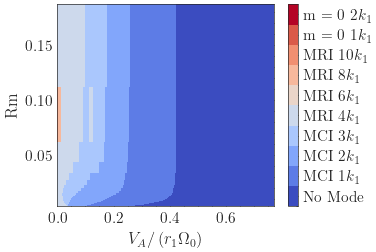

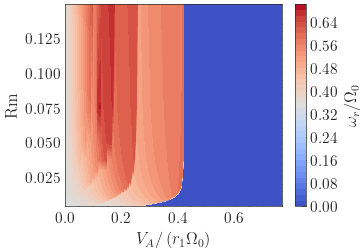

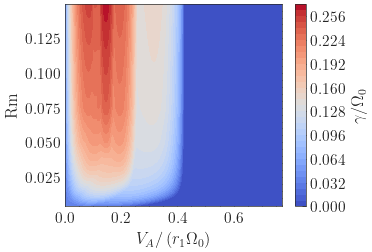

In [ ]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]
cmap = 'coolwarm'
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7,8,9])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$', r'm = 0 $2k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
plt.savefig('Rm-vA-Tanh-dommode-qmagpi-m0.png', dpi = 400)
plt.show()

# ################ Zoom
# fig = plt.figure()
# levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # Add a colorbar


# tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
# cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# # Add a label to the colorbar
# # plt.title(r'Dominant Mode (Rm vs $V_A$)')
# # plt.legend()
# plt.ylim(np.min(Rm), 250)
# # plt.ylim(0, 250)
# plt.axvline(x = VAm, linestyle = '--', color = 'w')
# # plt.axhline(y = Rmm, linestyle = '--', color = 'k')
# # plt.plot(VAm, Rmm, 'o', color = 'k')
# plt.axhline(y = Rmm, linestyle = '--', color = 'w')
# plt.plot(VAm, Rmm, 'o', color = 'w')
# plt.text(0.2, 50, f'Rm = {np.round(Rmm,1)}', fontsize=12, color = 'w', fontweight = 'heavy')
# plt.text(0.2, 50, r'$\mathrm{Rm}^{min}= $' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(0.15, 50, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(0.2, 50, r'min(Rm) =' +  f' {np.round(Rmm,1)}', fontsize=12, color = 'w', weight = 'extra bold')

# plt.axhline(y = Rmm, linestyle = '--')
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7,8,9])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.ylim(np.min(Rm), 250)
plt.savefig('Rm-vA-Tanh-dommode-freq-m0.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]

gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


# plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)

plt.show()

# Sat

# Standard

### Import Standard

In [593]:
import os

path_home = os.getcwd()
b = os.listdir()
# print(b)
# os.chdir('Shooting-AlfvenSweep-Scaled-Data/')
# b = os.listdir()
# os.chdir(path_home)


# print(b)
dt = 5
eta_arr = np.arange(dt, 500 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done

diff_modes = ['m=0_1k1', 'm=0_2k1', 'MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1', 'm=0_2k1', 'm=0_3k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['m=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1', 'm=0_1k1'] # ad 10k1 when done

# diff_modes = ['MCI_1k1'] # ad 10k1 when done

print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    
    # ### WKB jawns.
    # if(diff_modes[k] ==  'MCI_1k1'):
    #     eta_arr = np.arange(dt, 500 + dt, dt)
    # elif(diff_modes[k] ==  'MCI_2k1'):
    #     eta_arr = np.arange(dt, 165 + dt, dt)
    # elif(diff_modes[k] ==  'MCI_3k1'):
    #     eta_arr = np.arange(dt, 100 + dt, dt)
    # elif(diff_modes[k] ==  'MRI_4k1'):
    #     eta_arr = np.arange(dt, 55 + dt, dt)
    # elif(diff_modes[k] ==  'MRI_6k1'):
    #     eta_arr = np.arange(dt, 25 + dt, dt)
    # elif(diff_modes[k] ==  'MRI_8k1'):
    #     eta_arr = np.arange(dt, 25 + dt, dt)
    # elif(diff_modes[k] ==  'MRI_10k1'):
    #     eta_arr = np.arange(dt, 20 + dt, dt)

    ### qmagpi jawns.
    if(diff_modes[k] ==  'MCI_1k1'):
        eta_arr = np.arange(dt, 300 + dt, dt)
    elif(diff_modes[k] ==  'MCI_2k1'):
        eta_arr = np.arange(dt, 165 + dt, dt)
    elif(diff_modes[k] ==  'MCI_3k1'):
        eta_arr = np.arange(dt, 120 + dt, dt)
    elif(diff_modes[k] ==  'MRI_4k1'):
        eta_arr = np.arange(dt, 55 + dt, dt)
    elif(diff_modes[k] ==  'MRI_6k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_8k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_10k1'):
        eta_arr = np.arange(dt, 20 + dt, dt)

    for l in eta_arr:
        # print(eta_arr)
        # print(l)
        elecd_str = f'{l}'

        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        ### WKB 1k1 weird....

        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'
        
        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'
        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])

        # print(len(e12))
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 3):
            VA_N_total = VA12
        elif(k == 0):
            VA_N_total_MCI = VA12
        elif(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12

        # print(len(e12))
        # print(len(gr_tot))
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 500 + dt, dt)


e11 = np.zeros((1602, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1602, len(eta_arr), len(diff_modes)))


### Note we couldn't do Sat to all 0 for MCI 1k1, 2k1
print('Printing minima of vA')
print(np.min(VA_N_total_MCI))
print(np.min(VA_N_total))
jj = np.where(VA_N_total == np.min(VA_N_total_MCI))[0]
print(jj)

for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        if(diff_modes[k] == 'MCI_1k1'):
            len_diff = int(jj)
            # print(len(e))
            # print(eta_arr[k])
            print(len(e[k][j][:]))
            e11[len_diff:1602,j,k] = e[k][j][:]
            print(e11[:,j,k])
            f11[len_diff:1602,j,k] = f1[k][j][:]
        else:
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]
            
print(np.shape(e11))
e11j = np.zeros(np.shape(e11))
# e11j[:,:,:] = e11[:,:,:]

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            e11j[i,j,k] = e11[i,j,k]
            

[  5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85  90
  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180
 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265 270
 275 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355 360
 365 370 375 380 385 390 395 400 405 410 415 420 425 430 435 440 445 450
 455 460 465 470 475 480 485 490 495 500]
7
7
Printing minima of vA
0.04627268132965006
0.0
[96]
1506
[ 0.          0.          0.         ... -0.00604902 -0.00604854
 -0.00604806]
1506
[ 0.          0.          0.         ... -0.01209866 -0.01209769
 -0.01209672]
1506
[ 0.          0.          0.         ... -0.01814952 -0.01814807
 -0.01814662]
1506
[ 0.          0.          0.         ... -0.02420224 -0.02420029
 -0.02419834]
1506
[ 0.          0.          0.         ... -0.03025742 -0.03025496
 -0.0302525 ]
1506
[ 0.          0.          0.         ... -0.03631566 -0.03631268
 -0.03630971]
1506
[ 0.          0.          0. 

C:\Users\Alex\AppData\Local\Temp\ipykernel_36852\1919755714.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  len_diff = int(jj)


### Freq

(array([   0,    0,    0, ..., 1601, 1601, 1601], dtype=int64), array([ 0,  0,  0, ..., 57, 58, 59], dtype=int64), array([1, 3, 4, ..., 0, 0, 0], dtype=int64))
(array([ 801,  802,  803, ..., 1601, 1601, 1601], dtype=int64), array([3, 3, 3, ..., 1, 2, 3], dtype=int64))
(array([ 801,  802,  803, ..., 1601, 1601, 1601], dtype=int64), array([3, 3, 3, ..., 1, 2, 3], dtype=int64))


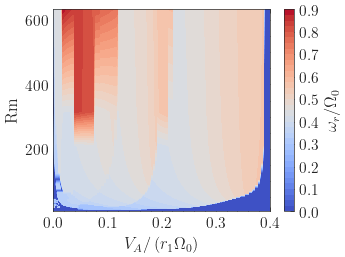

In [594]:
### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii_abs = -np.ones((1602, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11j[i,j,k] > gr_ijk_ii_abs[i,j]):
                gr_ijk_ii_abs[i,j] = e11j[i,j,k] 
# print(e11j)
print(np.where(e11j < 0))
print(np.where(gr_ijk_ii_abs < 0))       



e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k] 
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)

ii = np.where(gr_ijk_ii_abs <= 0)
gr_ijk_ii[ii[:]] = 0
    
ii = np.where(gr_ijk_ii_abs == -1)
gr_ijk_ii_abs[ii[:]] = 0

print(np.where(gr_ijk_ii_abs < 0))
fig = plt.figure()

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.4)
plt.savefig('Rm-vA-Sat-freq-WKB.png', dpi = 400)
plt.savefig('Rm-vA-Sat-freq-WKB.svg', format = 'svg')

plt.show()

### Gr - Eta

7
[0. 1. 2. 3. 4. 5. 6. 7.]


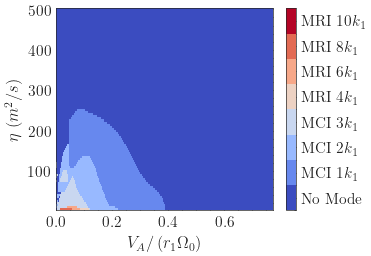

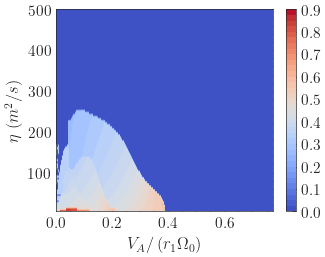

0.07615712135504907
[  5   5   5 ... 250 250 250]
Minimum Rm: 12.649110640673518
250


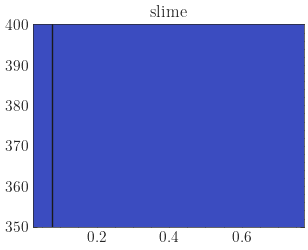

(array([49], dtype=int64),)
(array([206, 207, 208, 209, 210], dtype=int64),)
neq 0
(array([], dtype=int64),)
0.0
0.0
0.11253218452678022
390


In [595]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5,6,7,8]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

ij = 50
gr_temp = gr_ijk_ii_plot[0:len(eta_arr),ij:len(VA_N_total)]
plt.figure()
plt.title('slime')
contour = plt.pcolormesh(VA_N_total[ij:len(VA_N_total)], eta_arr, gr_temp, cmap=cmap, norm=norm)

ii = np.where(gr_temp == 1)
jj = np.where(eta_arr[ii[0][:]] == np.max(eta_arr[ii[0][:]]))
kk = VA_N_total[ij:len(VA_N_total)][ii[1][:]][jj[:]]

VAm = kk[0]
print(VAm)
print(eta_arr[ii[0][:]])
Rmm = r1**2*Omega0/np.max((eta_arr[ii[0][:]]))
print(f'Minimum Rm: {Rmm}')
print(np.max(eta_arr[ii[0][:]]))
plt.axhline(y = np.max(eta_arr[ii[0][:]]), color = 'k')
plt.axvline(x = VAm, color = 'k')
plt.ylim(350,400)
plt.show()

tol = 1E-3
print(np.where(eta_arr == np.max(eta_arr[ii[0][:]])))
print(np.where(np.abs(VA_N_total - 0.1) < tol))

print('neq 0')
print(np.where(gr_ijk_ii_abs[:, 77]!= 0))
print(gr_ijk_ii_abs[279, 77])
print(freq_ijk[279, 77])
print(VA_N_total[234])
print(eta_arr[77])
# print(gr_ijk[77, 206])

In [596]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)

display(eta_arr[gr_ii[0][:]])
VA_N_total[gr_ii[1][:]]
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
kk = VA_N_total[gr_ii[1][:]][jj[:]]

# VAm = kk[0]
# print(VAm)
# Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
# print(f'Minimum Rm: {Rmm}')

array([  5,   5,   5, ..., 250, 250, 250])

### GR - Rm

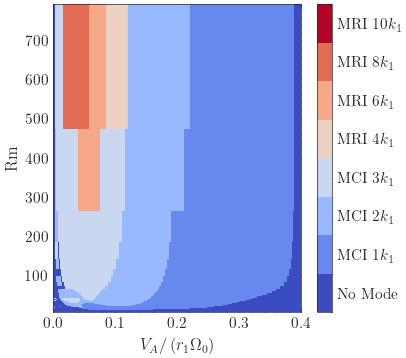

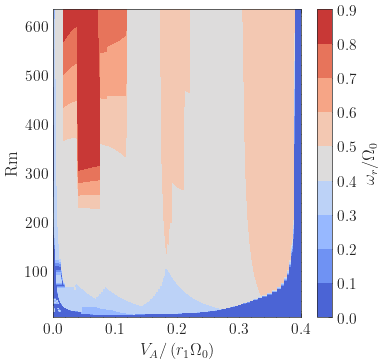

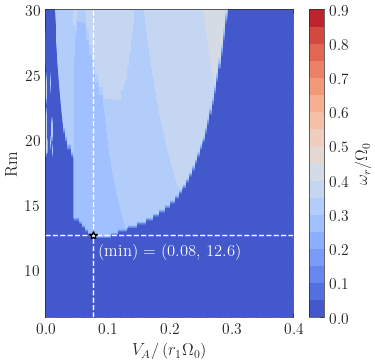

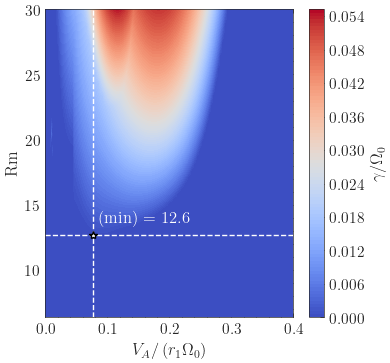

In [590]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7]
cmap = 'coolwarm'
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.xlim(0,0.4)
plt.savefig('Rm-vA-Sat-dommode-qmagpi.png', dpi = 400)
plt.savefig('Rm-vA-Sat-dommode-qmagpi.svg', format = 'svg', dpi = 300)
plt.show()



################ Zoom
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8,9]
contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),10, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
tickss = np.array([0,1,2,3,4,5,6,7,8,9])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.xlim(0,0.4)
plt.savefig('Rm-vA-Sat-freq-qmagpi.png', dpi = 400)
plt.savefig('Rm-vA-Sat-freq-qmagpi.svg', format = 'svg')
plt.show()

################ Zoom
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8,9,10]
gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, (np.transpose(freq_ijk)), cmap=cmap, levels = 20)
cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.ylim(np.min(Rm),30)
plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.text(VAm + 0.01, Rmm-1.5, f'(min) = {(np.round(VAm, 2), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')


plt.xlim(0,0.4)
plt.savefig('Rm-vA-Sat-freq-qmagpi-zoom.png', dpi = 400)
plt.savefig('Rm-vA-Sat-freq-qmagpi-zoom.svg', format = 'svg')
plt.show()

################ Zoom
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8,9,10]
gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm[20:len(Rm)], (np.transpose(gr_ijk_ii_abs))[20:len(Rm), :], cmap=cmap, levels = 100)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.ylim(np.min(Rm),30)
plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.text(VAm + 0.01, Rmm+1, f'(min) = {np.round(Rmm, 1)}', fontsize=12, color='w', fontweight='bold')


plt.xlim(0,0.4)
plt.savefig('Rm-vA-Sat-Gr-qmagpi-zoom.png', dpi = 400)
plt.savefig('Rm-vA-Sat-Gr-qmagpi-zoom.svg', format = 'svg')
plt.show()




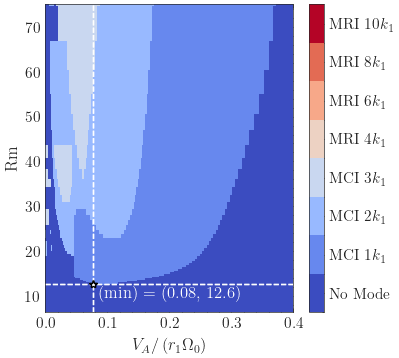

In [597]:
########### MINIMA Mode
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)
levels = [0,1,2,3,4,5,6,7,8]
cmap = 'coolwarm'
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
tickss = np.array([0,1,2,3,4,5,6,7])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylim(np.min(Rm),75)
plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.text(VAm + 0.01, Rmm-3, f'(min) = {(np.round(VAm, 2), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')

plt.xlim(0,0.4)
plt.savefig('Rm-vA-Sat-dommode-qmagpi-zoom.png', dpi = 400)
plt.savefig('Rm-vA-Sat-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
plt.show()

# 

# qmag0 MCI

### Import

In [ ]:
import os

path_home = os.getcwd()
b = os.listdir()


# print(b)
dt = 25
eta_arr = np.arange(dt, 600 + dt, dt)
r1 = 0.1 # cm to m
V0 = r1*Omega0
Rm = r1*V0/eta_arr
print(eta_arr)
# e = []
# f1 = []
# diff_modes = ['MCI_1k1'] ### ad 10k1 when done

diff_modes = ['m=0_1k1', 'm=0_2k1', 'MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] ### ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1', 'm=0_1k1', 'm=0_2k1', 'm=0_3k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1', 'MCI_2k1','MCI_3k1','MRI_4k1', 'MRI_6k1','MRI_8k1','MRI_10k1'] # ad 10k1 when done
diff_modes = ['MCI_1k1'] # ad 10k1 when done


print(len(diff_modes))
print(len(diff_modes))

# str_fit = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[0] + '_guessesu_'
# print(len(str_fit))
# # print(b)
# matches = [int(x[50:]) for x in b if x[:50] == str_fit]
# print(matches)

e = []
f1 = []
for k in range(0,len(diff_modes)):
    d = []
    d1 = []
    # if(diff_modes[k] ==  'MCI_1k1'):
    #     eta_arr = np.arange(dt, 100 + dt, dt)
    if(diff_modes[k] ==  'MCI_2k1'):
        eta_arr = np.arange(dt, 165 + dt, dt)
    elif(diff_modes[k] ==  'MCI_3k1'):
        eta_arr = np.arange(dt, 100 + dt, dt)
    elif(diff_modes[k] ==  'MRI_4k1'):
        eta_arr = np.arange(dt, 55 + dt, dt)
    elif(diff_modes[k] ==  'MRI_6k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_8k1'):
        eta_arr = np.arange(dt, 25 + dt, dt)
    elif(diff_modes[k] ==  'MRI_10k1'):
        eta_arr = np.arange(dt, 20 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_1k1'):
    #     eta_arr = np.arange(1, 38 + dt, dt)
    # elif(diff_modes[k] ==  'm=0_2k1'):
    #     eta_arr = np.arange(1, 128 + dt, dt)
    elif(diff_modes[k] ==  'm=0_3k1'):
        eta_arr = np.arange(5, 115 + dt, dt)
    else:
        eta_arr = np.arange(dt, 570 + dt, dt)

    for l in eta_arr:
        # print(eta_arr)
        # print(l)
        elecd_str = f'{l}'

        # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat2-PM0.pkl'
        ### WKB 1k1 weird....


        ## qmag0
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3d-Sat-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3d-Sat-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3d-Sat-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3d-Sat-PM0.pkl'

        ## 2pi r1/(r2-r1)
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-div2-Sat-PM0.pkl'

        ## pi r1/(r2-r1)
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-Sat-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-Sat-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-Sat-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-Sat-PM0.pkl'

        ## pi r1/(r2-r1)
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'

        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])

        # print(len(e12))
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        # print(len(e12))
        # print(len(gr_tot))
        # print(len(gr_tot))
        # print(j)
        d.append(gr_tot)
        d1.append(f12)

    # print(len(d))
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(dt, 600 + dt, dt)


e11 = np.zeros((1602, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1602, len(eta_arr), len(diff_modes)))


e11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))

for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        
        if(diff_modes[k] == 'm=0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
    
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

[ 25  50  75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450
 475 500 525 550 575 600]
7
7


FileNotFoundError: [Errno 2] No such file or directory: 'Shooting-AlfvenSweep-Scaled-Data/MCI_2k1_guessesd_25-kep-Bz-res-divr-WKB-div2-Sat-PM0.pkl'

### Freq

(array([   0,    0,    0, ..., 1505, 1505, 1505], dtype=int64), array([ 1,  3,  4, ..., 20, 21, 22], dtype=int64), array([0, 0, 0, ..., 0, 0, 0], dtype=int64))


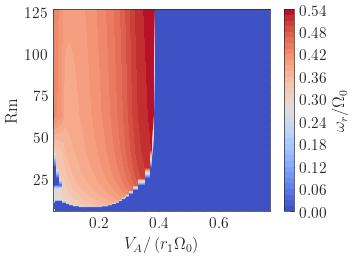

In [ ]:
e11_both = np.zeros((len(e[0][0]), len(eta_arr), len(diff_modes)))
e11_both[:,:,:] = e11[:,:,:]

print(np.where(e11_both < 0))

e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

# Gr0 = e11[0,0,0]
# # Gr0 = 0.01857696031459291
# print(f'Gr = {Gr0}')

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))

# gr_ijk = np.zeros((len(e[0][0]), len(eta_arr)))
gr_ijk = np.zeros((len(e[0][0]), len(eta_arr)))
gr_ijk_ii = np.zeros((len(e[0][0]), len(eta_arr)))
freq_ijk = np.zeros((len(e[0][0]), len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            e11[i,j,k] = e11[i,j,k] 
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k] 
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                    
gr_ijk_both = np.ones((len(e[0][0]), len(eta_arr)))   
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            gr_ijk_both[i,j] = e11_both[i,j,k] 


Rm = r1**2*Omega0/(eta_arr)
# #############
fig = plt.figure()
plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.show()

### GR - Eta

1
[0. 1.]


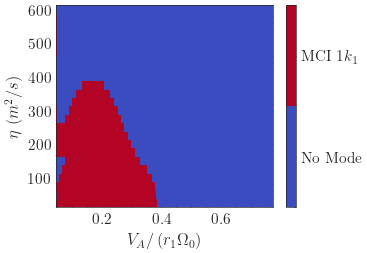

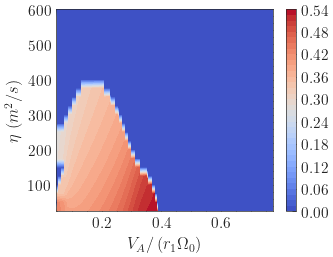

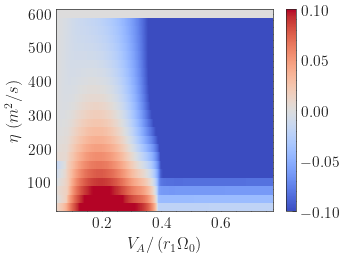

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2]
# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
cbar = plt.colorbar(contour)
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
# contour = plt.contourf(VA_N_total, eta_arr, np.transpose(gr_ijk_both), 40, cmap ='coolwarm', clim=(-0.1, 0.1))
contour = plt.pcolormesh(VA_N_total, eta_arr, np.transpose(gr_ijk_both), cmap ='coolwarm', clim=(-0.1, 0.1))

cbar = plt.colorbar(contour)
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()


### Rm vs VA

In [ ]:
j_mark = 0
k_mark = 0
# print(diff_modes[7])
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
# print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

0.04627268132965006
Minimum Rm: 5.499613322031965


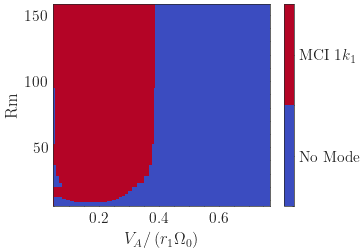

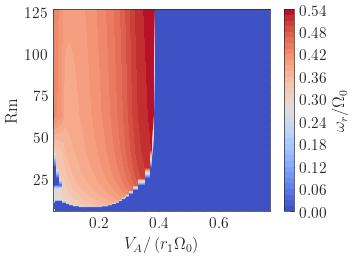

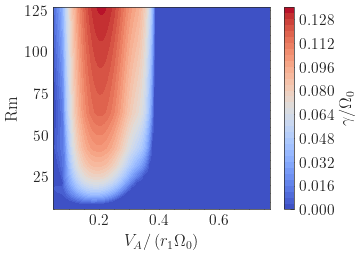

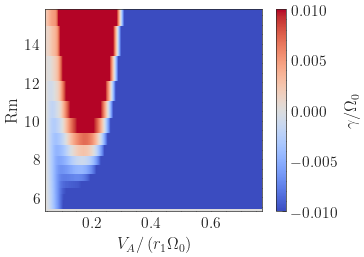

In [ ]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]
cmap = 'coolwarm'
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7,8,9])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$', r'm = 0 $2k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.savefig('Rm-vA-Tanh-dommode-qmagpi-m0.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4,5,6,7,8,9])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.ylim(np.min(Rm), 250)
# plt.savefig('Rm-vA-Tanh-dommode-freq-m0.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5,6,7,8,9,10]

gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
# plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)
plt.show()

############# zoooooom

fig = plt.figure()
contour = plt.pcolormesh(VA_N_total, Rm, np.transpose(gr_ijk_both), cmap=cmap, clim=(-0.01, 0.01))
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')
plt.ylim(np.min(Rm), 3*np.min(Rm))
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.xlim(0,0.3)
# Add a colorbar
# plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)
plt.show()




# fig = plt.figure()
# levels = [0,1,2]
# cmap = 'coolwarm'
# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# tickss = np.array([0,1])+ 0.5
# cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$'])
# plt.xlim(0,0.3)
# plt.ylim(np.min(Rm), 8)
# plt.axvline(x = VAm, linestyle = '--', color = 'w')
# plt.axhline(y = Rmm, linestyle = '--', color = 'w')
# plt.plot(VAm, Rmm, 'o', color = 'w')
# plt.text(0.15, 10, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.show()


# #### Plot Slice
# tol = 1E-3
# ii = np.where(np.abs(VA_N_total - 0.3) < tol)
# print(ii)
# ## 525
# ii = np.where(np.abs(Rm-5.100447838981257) < tol)
# # ii = np.where(np.abs(Rm-4) < tol)
# print(ii)
# ## 123

# VA_N_Cut = np.zeros(525)
# Rm_Cut = np.zeros(123)
# gr_ijk_cut = np.zeros((525, 123))
# for j in range(0,len(VA_N_Cut)):
#     VA_N_Cut[j] = VA_N_total[j]
#     for k in range(0,len(Rm_Cut)):
#         gr_ijk_cut[j][k] = gr_ijk_both[j][k]
#         Rm_Cut[k] = Rm[len(Rm)-1-k]

# fig = plt.figure()
# levels = [0,1,2]
# cmap = 'coolwarm'
# # print(Rm_Cut)
# contour = plt.contourf(VA_N_Cut, np.flip(Rm_Cut), np.transpose((gr_ijk_cut)),40, cmap ='coolwarm')
# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# cbar = plt.colorbar(contour) 
# plt.xlim(0,0.3)
# plt.show()



# Kep.

## Import

In [20]:
dt = 1
eta_arr = np.arange(dt, 100, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1'] ### ad 10k1 when done
diff_modes = ['MRI_1k1']
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_1k1', 'MRI_2k1']
# diff_modes = ['MRI_1k1','MRI_2k1']

# diff_modes = ['MRI_1k1', 'MRI_2k1'] 
# diff_modes = ['MRI_1k1'] 

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 65, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 36, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 19, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 33, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-qmagpi.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-qmagpi.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-qmagpi.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-qmagpi.pkl'
    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)

        # if(diff_modes[k] == 'MCI_1k1'):
        #     gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = np.array(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        #     VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = np.array(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)
        #     # print('herm')
        #     if(n == 35):
        #         plt.plot(VA_h_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        #         plt.show()
        #         ii = np.where(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 < 0)
        #         ij = np.where(VA_h_MCI1_Bz_ETA1_divr_WKB_div4 == np.min(VA_h_MCI1_Bz_ETA1_divr_WKB_div4[ii[:]]))
        #         VAm = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[ij[:]][0]
        #         print(VAm)
        #         print('huh')
        #     if(n == 36):
        #         VAm = VAm - 0.005
        #         # print(j == 36)
        #         # print('bruh')
        #         ii = np.where(VA_h_MCI1_Bz_ETA1_divr_WKB_div4 > VAm)
        #         # print
        #         # print(ii)
        #         gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] = 0
        #         # plt.plot(VA_h_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        #         # plt.show()
                
        #     elif(n > 36):
        #         VAm = VAm - 0.001
        #         # print(j == 36)
        #         # print('bruh')
        #         ii = np.where(VA_h_MCI1_Bz_ETA1_divr_WKB_div4 > VAm)
        #         # print
        #         # print(ii)
        #         gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[ii[:]] = 0
        #         # plt.plot(VA_h_MCI1_Bz_ETA1_divr_WKB_div4, gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)
        #         # plt.show()
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        # e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        # VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
    
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        # print(len(gr_tot))
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
eta_arr = np.arange(1, 100, 1)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(len(e[k][j]))
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

(1602, 99, 4)


## Freq

KeyboardInterrupt: 

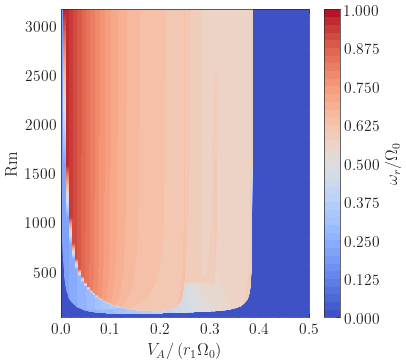

In [21]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0



### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
                

Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

# plt.contourf(VA_N_total, eta_arr, np.transpose((gr_ijk)),40, cmap ='coolwarm')
# plt.ylabel(r'Rm')
# plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# # Add a colorbar
# cbar = plt.colorbar()
# # Add a label to the colorbar
# cbar.set_label(r'$\omega_r/\Omega_0$')
# # plt.title(r'Dominant Mode at fixed Rm and $V_A$')
# # plt.savefig('Rm-vA-Kep-freq-qmagpi-m0.png', dpi = 400)
# plt.show()


## Eta 

4
[0. 1. 2. 3. 4.]


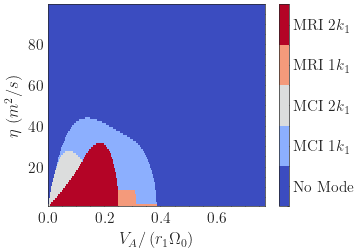

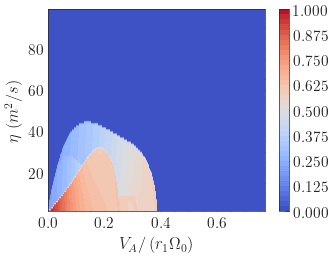

In [ ]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j
print(nticks)
print(ticks_arr)

ticks_arr = ticks_arr +0.5
# print(ti
levels = [0,1,2,3,4,5]
# levels = [0,1,2,3,4]
# levels = [0,1,2,3]
# levels = [0,1,2]

# levels = [0,1,2,3,4,5,6,7,8,9]
# levels = [0,1,2,3,4,5,6,7,8,9,10,11]
# pick the desired colormap, sensible levels, and define a normalization
# instance which takes data values and translates those into levels.
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
# cbar.ax.set_yticklabels(['No Mode',r'MRI $1k_1$', r'MRI $2k_1$'])
# cbar.ax.set_yticklabels(['No Mode',r'MCI $1k_1$',r'MRI $1k_1$'])

# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', r'm = 0 $1k_1$'])

# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Sat2-dommode-qmagpi.png', dpi = 400)
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$', 'm = 0 $1k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$',  r'MCI $3k_1$',  r'MRI $2k_1$',  r'MRI $3k_1$',  r'MRI $4k_1$',  r'MRI $5k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# plt.title(r'Dominant Mode at fixed $\eta$ and $V_A$')
# plt.savefig('Eta-vA-Kep-dommode-qmagpi.png', dpi = 400)
plt.show()

## Rm 

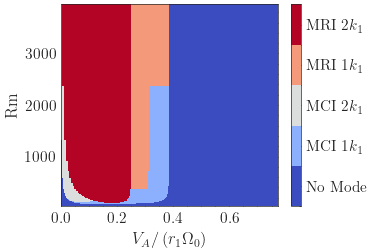

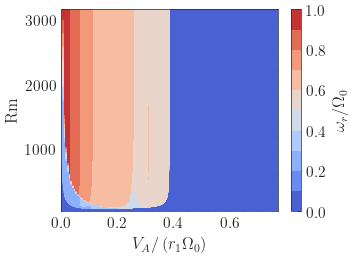

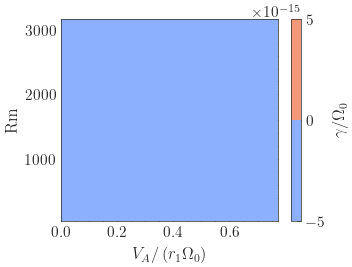

In [ ]:

### Coolwarm good cmap
# Spectral OK
# RdGy OK
fig = plt.figure()
levels = [0,1,2,3,4,5]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.savefig('Rm-vA-Tanh-dommode-qmagpi.png', dpi = 400)
plt.show()


################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5]

contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),10, cmap ='coolwarm')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour) 
cbar.set_label(r'$\omega_r/\Omega_0$')
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MCI $3k_1$', r'MRI $4k_1$', r'MRI $6k_1$', r'MRI $8k_1$', r'MRI $10k_1$'])

# Add a label to the colorbar
# plt.title(r'Dominant Mode (Rm vs $V_A$)')
# plt.legend()
# plt.ylim(np.min(Rm), 250)
# plt.savefig('Rm-vA-Tanh-dommode-freq.png', dpi = 400)
plt.show()

################ Zoom
fig = plt.figure()
levels = [0,1,2,3,4,5]

gr_ijk_log = np.zeros(np.shape(gr_ijk))
gr_ijk_jj = np.where(gr_ijk != 0)
gr_ijk_log[gr_ijk_jj[:]] = np.log(gr_ijk[gr_ijk_jj[:]])
contour = plt.contourf(VA_N_total, Rm, np.transpose(gr_ijk), cmap=cmap, levels = 40)
cbar = plt.colorbar()
cbar.set_label(r'$\gamma/\Omega_0$')

plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar


# plt.savefig('Rm-vA-Kep-Gr-qmagpi.png', dpi = 400)

plt.show()

## Rm Specifics

In [ ]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

44
0.1308484542197667
Minimum Rm: 71.86994682200863


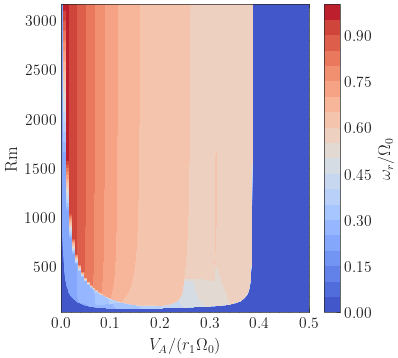

In [ ]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)


# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm,zorder=-20 )
contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)), 20, cmap=cmap)
# plt.ylim(np.min(Rm),np.max(Rm))
# ax2.set_rasterization_zorder(-10)
# ax2.grid(False)

cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.ylim(np.min(Rm), np.max(Rm) + 1000)

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.xlim(0, 0.5)
plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
# plt.savefig('Rm-vA-Kep-freq-qmagpi.pdf')

plt.show()

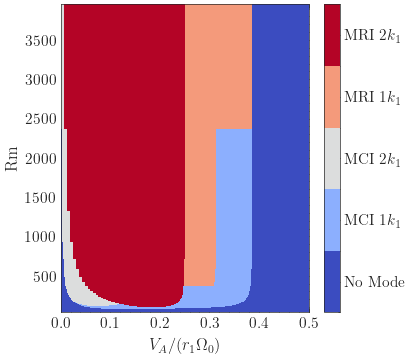

In [ ]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm,zorder=-20 )
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# ax2.set_rasterization_zorder(-10)
# ax2.grid(False)

tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])




lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
# plt.ylim(np.min(Rm), 250)
plt.xlim(0, 0.5)
plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.png', dpi = 400)
plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')

plt.show()

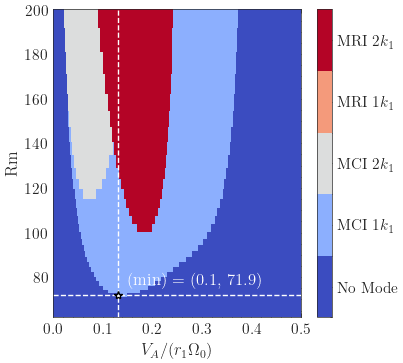

In [ ]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm,zorder=-20 )
contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# ax2.set_rasterization_zorder(-10)
# ax2.grid(False)

tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])

plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.text(VAm + 0.02, Rmm+5, f'(min) = {(np.round(VAm,1), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')


lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(np.min(Rm)+30, 200)
plt.xlim(0, 0.5)
plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.png', dpi = 400)
plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')

plt.show()

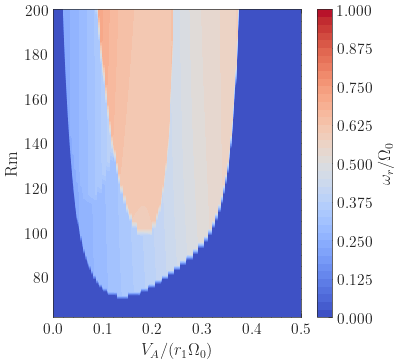

In [ ]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)


# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm,zorder=-20 )
contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)), 40, cmap=cmap)
plt.ylim(np.min(Rm),np.max(Rm))
# ax2.set_rasterization_zorder(-10)
# ax2.grid(False)

cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')


lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
# lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(np.min(Rm)+30, 200)
plt.xlim(0, 0.5)
plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi-zoom.png', dpi = 400)
plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi-zoom.svg', format = 'svg')
# plt.savefig('Rm-vA-Kep-freq-qmagpi-zoom.pdf')

plt.show()

# Exp6 Scan

In [22]:
dt = 1
eta_arr = np.arange(dt, 150, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_2k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_1k1']
# diff_modes = ['MCI_2k1', 'MRI_2k1']


# diff_modes = ['MRI_1k1', 'MRI_2k1'] 
# diff_modes = ['MRI_1k1'] 

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 100, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 100, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 10, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 23, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi.pkl'
    
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    
eta_arr = np.arange(1, 150, 1)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(len(e[k][j]))
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

(1602, 149, 3)


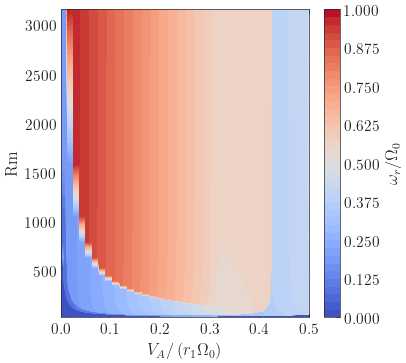

In [23]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()


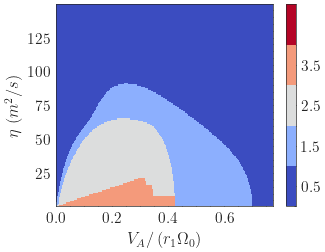

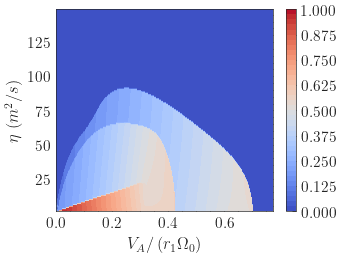

In [24]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$'])

plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
cbar = plt.colorbar(contour)
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

In [25]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

91
0.2448266600380985
Minimum Rm: 34.75030395789428


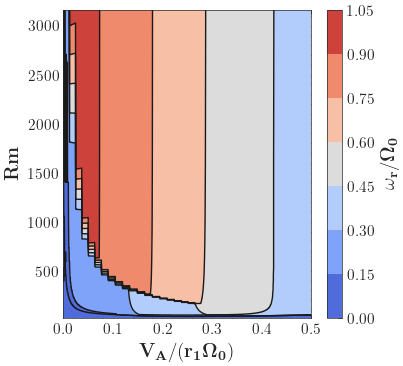

In [26]:
################ Zoom
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)


contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)), 7, cmap=cmap)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbf{\omega_r/\Omega_0}$', fontsize = 14)
plt.contour(contour, colors='k')

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.xlim(0, 0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

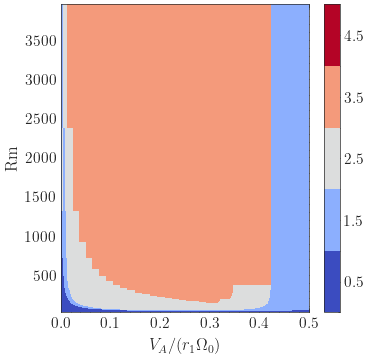

In [27]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
# plt.ylim(np.min(Rm), 250)
plt.xlim(0, 0.5)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')

plt.show()

0.2448266600380985


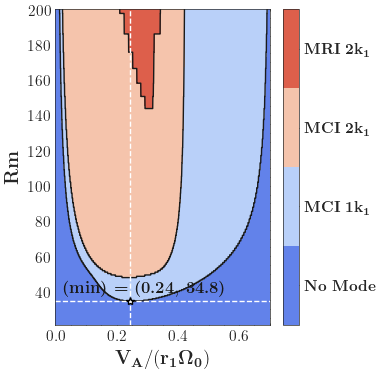

In [28]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
levels =np.array([0,1,2,3,4])
contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
# plt.text(VAm + 0.02, Rmm+5, f'(min) = {(np.round(VAm,1), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')
plt.text(VAm - 0.22, Rmm+5, r'\textbf{(min) = (0.24, 34.8)}', fontsize=12, color='k', fontweight='bold')
print(VAm)
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(np.min(Rm), 200)
plt.xlim(0, 0.7)
plt.tight_layout()
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')
plt.savefig('Rm-vA-Exp3-dommode-qmagpi-zoom-qrcomp.pdf')

plt.show()

# Kep Scan 

In [97]:
dt = 1
eta_arr = np.arange(dt, 150, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1',  'MRI_2k1']
# diff_modes = ['MRI_1k1','MRI_2k1']

# diff_modes = ['MRI_1k1', 'MRI_2k1'] 
# diff_modes = ['MRI_1k1'] 

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 100, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 50, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 100, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
    
        VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    
eta_arr = np.arange(1, 150, 1)
e11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
f11 = np.zeros((len(gr_tot), len(eta_arr), len(diff_modes)))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        # print(len(e[k][j]))
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

(1602, 149, 3)


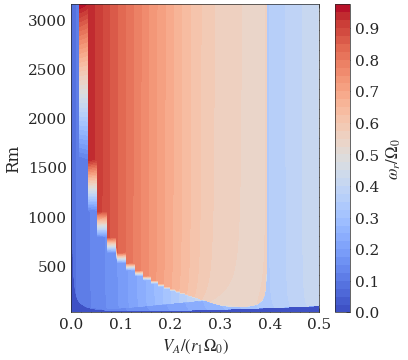

In [98]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

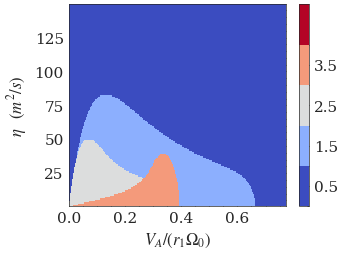

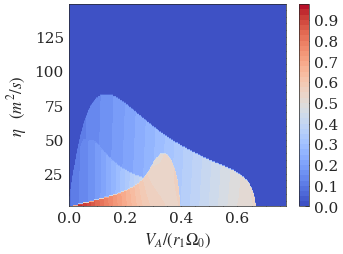

In [99]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
cbar = plt.colorbar(contour)
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

In [100]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

82
0.11278966074102202
Minimum Rm: 38.56436170937048


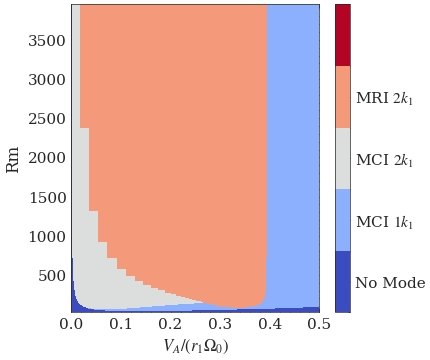

In [102]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $2k_1$'])
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
# plt.ylim(np.min(Rm), 250)
plt.xlim(0, 0.5)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')

plt.show()

0.11278966074102202


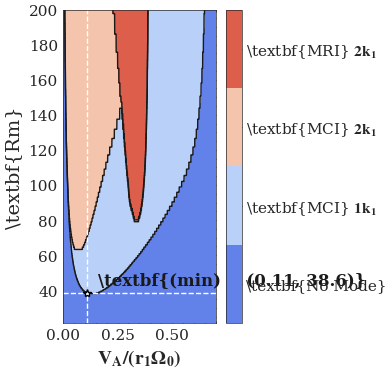

In [103]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
levels =np.array([0,1,2,3,4])
contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
# plt.text(VAm + 0.02, Rmm+5, f'(min) = {(np.round(VAm,1), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')
plt.text(VAm + 0.05, Rmm+5, r'\textbf{(min) = (0.11, 38.6)}', fontsize=12, color='k', fontweight='bold')
print(VAm)
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(np.min(Rm), 200)
plt.xlim(0, 0.7)
plt.tight_layout()
plt.savefig('Rm-vA-Kep-dommode-PM0.pdf')

plt.show()

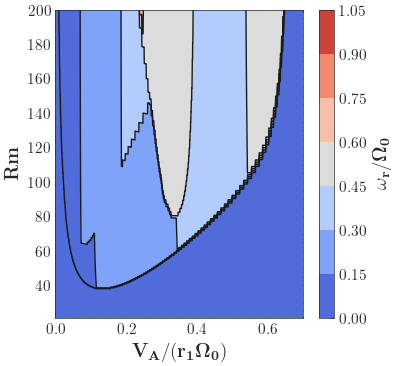

In [36]:
################ Zoom
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)


contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)), 7, cmap=cmap)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbf{\omega_r/\Omega_0}$', fontsize = 14)
plt.contour(contour, colors='k')

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(np.min(Rm), 200)
plt.xlim(0, 0.7)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

# Exp 6 Scan (Pm0)

In [9]:
dt = 1
eta_arr = np.arange(dt, 1000, dt)
e = []
f1 = []
# diff_modes = ['MCI_1k1', 'MCI_2k1', "m0_1k1"]
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_2k1', "m0_1k1"]
diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_2k1']

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 600, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 455, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 51, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 600, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'

        if(diff_modes[k] == 'MCI_2k1'):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
        elif(diff_modes[k] == 'MCI_1k1'):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
        else:
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    
eta_arr = np.arange(1, 600, 1)
e11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1570, len(eta_arr), len(diff_modes)))

e11 = np.zeros((1602, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1602, len(eta_arr), len(diff_modes)))

# print(np.shape(e11)
# for k in range(0,len(diff_modes)):
#     len_eta = len(e[k])
#     for j in range(0,len_eta):
#         # print(len(e[k][j]))
#         e11[0:len(e[k][j]),j,k] = e[k][j][:]
#         f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        
        if(diff_modes[k] == 'm0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]


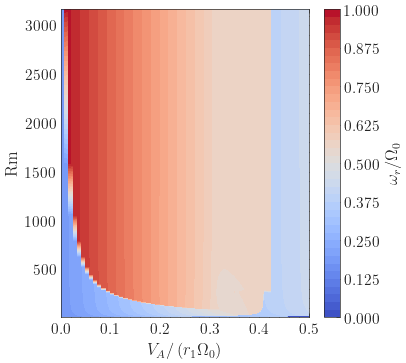

In [10]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1570, len(eta_arr)))
gr_ijk_ii = np.zeros((1570, len(eta_arr)))
freq_ijk = np.zeros((1570, len(eta_arr)))

gr_ijk = np.zeros((1602, len(eta_arr)))
gr_ijk_ii = np.zeros((1602, len(eta_arr)))
freq_ijk = np.zeros((1602, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

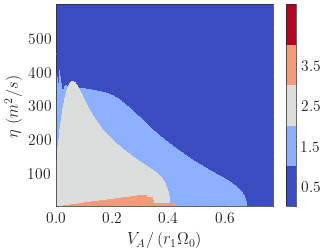

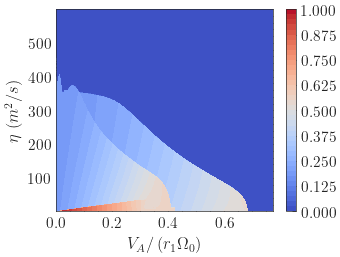

In [11]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
cbar = plt.colorbar(contour)
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

In [12]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

407
0.013496198721147936
Minimum Rm: 7.769723980757689


In [13]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

407
0.013496198721147936
Minimum Rm: 7.769723980757689


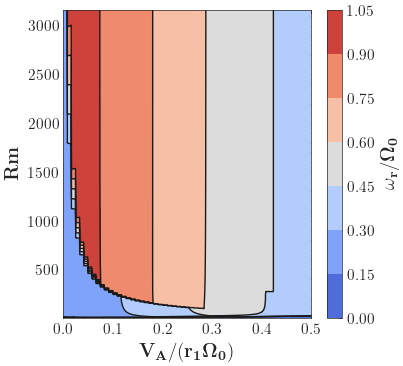

In [14]:
################ Zoom
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)


contour = plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)), 7, cmap=cmap)
cbar = plt.colorbar()
cbar.set_label(r'$\mathbf{\omega_r/\Omega_0}$', fontsize = 14)
plt.contour(contour, colors='k')

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.xlim(0, 0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

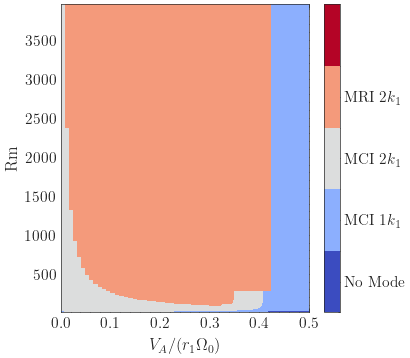

In [15]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $2k_1$'])
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
# plt.ylim(np.min(Rm), 250)
plt.xlim(0, 0.5)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')

plt.show()

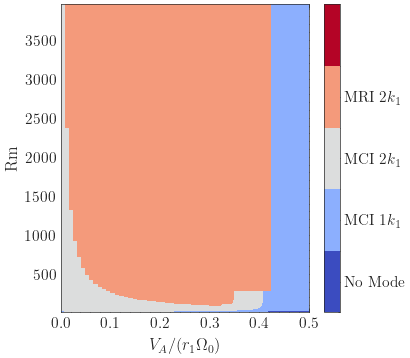

In [16]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3]

contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $2k_1$'])
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
# plt.ylim(np.min(Rm), 250)
plt.xlim(0, 0.5)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-dommode-qmagpi-zoom.svg', format = 'svg', dpi =300)
# plt.savefig('Rm-vA-Kep-dommode-qmagpi-zoom.pdf')

plt.show()

0.013496198721147936


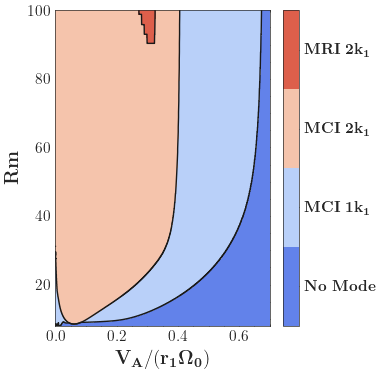

In [17]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
levels =np.array([0,1,2,3,4])
contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'MCI $\mathbf{2k_1}$', r'MRI $\mathbf{2k_1}$'])

# plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
# plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
# plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
# plt.text(VAm + 0.02, Rmm+5, f'(min) = {(np.round(VAm,1), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')
# plt.text(VAm + 0.02, Rmm+2, r'\textbf{(min) = (0.02, 3.98)}', fontsize=12, color='k', fontweight='bold')
print(VAm)
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(np.min(Rm), 20)
plt.ylim(8, 100)
plt.xlim(0, 0.7)
plt.tight_layout()
plt.savefig('Rm-vA-Exp6-PM0-dommode-qmagpi-zoom.pdf')

plt.show()

# Exp6 (Pm0, including m0)

In [18]:
dt = 1
eta_arr = np.arange(dt, 1000, dt)
e = []
f1 = []
# diff_modes = ['MCI_1k1', 'MCI_2k1', "m0_1k1"]
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_2k1', "m0_1k1"]
diff_modes = ['MCI_1k1', "m0_1k1"]

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 600, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 455, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 51, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 1000, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'

        if(diff_modes[k] == 'MCI_2k1'):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
        elif(diff_modes[k] == 'MCI_1k1'):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM0_1.pkl'
        elif(diff_modes[k] == 'm0_1k1' and j >= 434):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM0-l.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM0-l.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM0-l.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM0-l.pkl'
        else:
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM0.pkl'
        
        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    
eta_arr = np.arange(1, 1000, 1)
e11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1570, len(eta_arr), len(diff_modes)))

# e11 = np.zeros((1602, len(eta_arr), len(diff_modes)))
# f11 = np.zeros((1602, len(eta_arr), len(diff_modes)))

# print(np.shape(e11)
# for k in range(0,len(diff_modes)):
#     len_eta = len(e[k])
#     for j in range(0,len_eta):
#         # print(len(e[k][j]))
#         e11[0:len(e[k][j]),j,k] = e[k][j][:]
#         f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        
        if(diff_modes[k] == 'm0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]


In [19]:
# import matplotlib as mpl
# mpl.rcParams['text.usetex'] = False


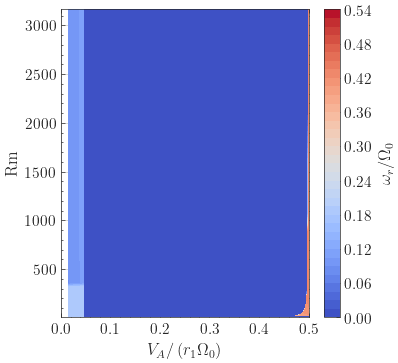

In [20]:
tol = 1E-4

e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

# e11_ii = np.where(e11 <= tol)
# e11[e11_ii[:]] = 0


### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1570, len(eta_arr)))
gr_ijk_ii = np.zeros((1570, len(eta_arr)))
freq_ijk = np.zeros((1570, len(eta_arr)))

# gr_ijk = np.zeros((1602, len(eta_arr)))
# gr_ijk_ii = np.zeros((1602, len(eta_arr)))
# freq_ijk = np.zeros((1602, len(eta_arr)))
for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
    
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)


plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

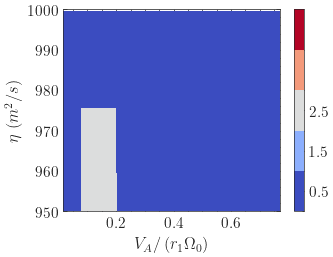

In [21]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.ylim(950,1000)
plt.show()


In [22]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

407
0.02892042583103129
Minimum Rm: 7.769723980757689


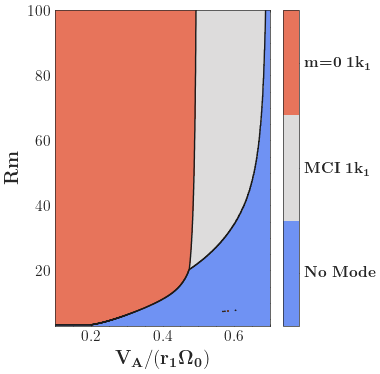

In [23]:
################ Zoom
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
levels =np.array([0,1,2,3])
contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{m=0} $\mathbf{1k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'm=0 $\mathbf{1k_1}$'])

# plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
# plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
# plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
# plt.text(VAm + 0.02, Rmm+5, f'(min) = {(np.round(VAm,1), np.round(Rmm, 1))}', fontsize=12, color='w', fontweight='bold')
# plt.text(VAm + 0.02, Rmm+2, r'\textbf{(min) = (0.02, 3.98)}', fontsize=12, color='k', fontweight='bold')
lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(np.min(Rm), 20)
plt.ylim(3, 100)
plt.xlim(0.1, 0.7)
plt.tight_layout()
plt.savefig('Rm-vA-Exp6-PM0-dommode-qmagpi-zoom-m0.pdf')
plt.show()

# Kep Scan (Pm0)

In [24]:
dt = 1
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1',  'MRI_2k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1']
# diff_modes = ['MCI_2k1']



for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 100, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 92, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 500, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'

        if(diff_modes[k] == "MCI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
        

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM0.pkl'
        
        if(diff_modes[k] == "m0_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    
eta_arr = np.arange(1, 1000, 1)
e11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        
        if(diff_modes[k] == 'm0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]


(1570, 999, 3)


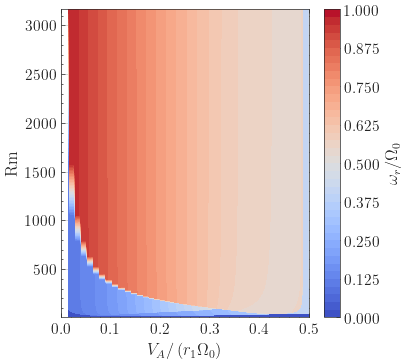

In [25]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1570, len(eta_arr)))
gr_ijk_ii = np.zeros((1570, len(eta_arr)))
freq_ijk = np.zeros((1570, len(eta_arr)))

# gr_ijk = np.zeros((1569, len(eta_arr)))
# gr_ijk_ii = np.zeros((1569, len(eta_arr)))
# freq_ijk = np.zeros((1569, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

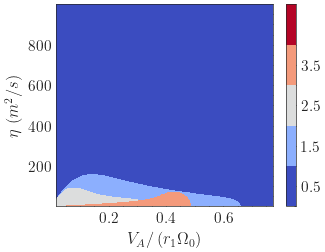

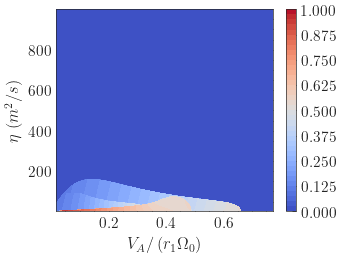

In [26]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
cbar = plt.colorbar(contour)
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

In [27]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

159
0.1322944755113183
Minimum Rm: 19.888538743197355


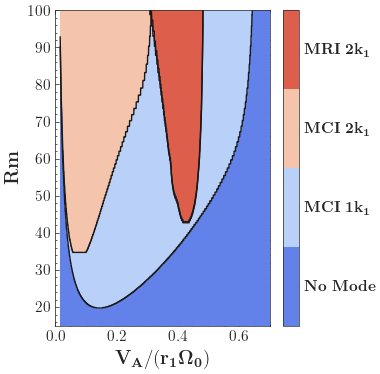

In [28]:
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# levels =np.array([0,1,2,3])
levels =np.array([0,1,2,3,4])

contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'MCI $\mathbf{2k_1}$', r'MRI $\mathbf{2k_1}$'])

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(15, 100)
plt.xlim(0, 0.7)
plt.tight_layout()
plt.savefig('Rm-vA-Kep-PM0-dommode-qmagpi-zoom.pdf')

plt.show()

# Kep (Pm0, m0)

In [29]:
dt = 1
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1',  'MRI_2k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1']
diff_modes = ['MCI_1k1',  'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1',  'MCI_2k1']

diff_modes = ['MCI_1k1', 'm0_1k1']



for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 449, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 55, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 292, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM0.pkl'
        
        if(diff_modes[k] == "m0_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    
eta_arr = np.arange(1, 1000, 1)
e11 = np.zeros((1569, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1569, len(eta_arr), len(diff_modes)))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        
        if(diff_modes[k] == 'm0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]


(1569, 999, 2)


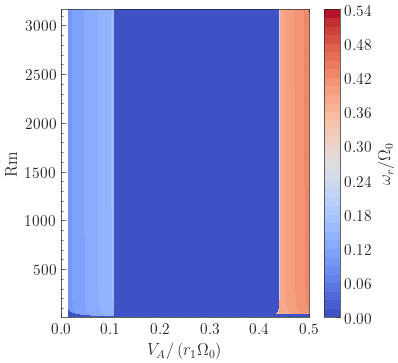

In [30]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1569, len(eta_arr)))
gr_ijk_ii = np.zeros((1569, len(eta_arr)))
freq_ijk = np.zeros((1569, len(eta_arr)))

# gr_ijk = np.zeros((1569, len(eta_arr)))
# gr_ijk_ii = np.zeros((1569, len(eta_arr)))
# freq_ijk = np.zeros((1569, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

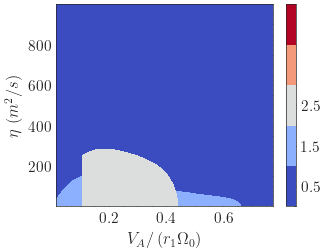

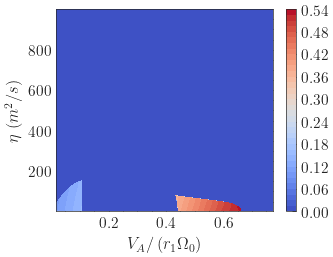

In [31]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
contour = plt.contourf(VA_N_total, eta_arr, np.transpose(freq_ijk), 40, cmap ='coolwarm')
cbar = plt.colorbar(contour)
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

In [32]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

152
0.10652356847763192
Minimum Rm: 20.804458290581444


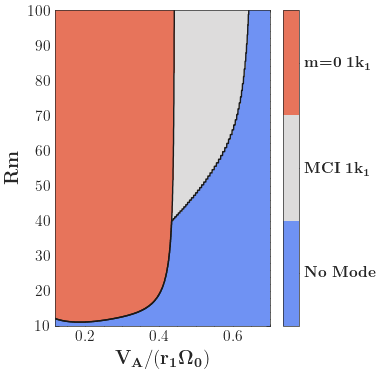

In [33]:
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# levels =np.array([0,1,2,3])
levels =np.array([0,1,2,3])

contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{m=0} $\mathbf{1k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'm=0 $\mathbf{1k_1}$'])

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# fig.legend(lines, labels, loc='lower center', ncol=2, 
#            bbox_to_anchor=(0.5, -0.15),  # Position the legend below the plot
#            frameon=False,  # Turn on the frame (border)
#            edgecolor='black',  # Set the border color
#            facecolor='white',  # Set the background color of the legend box
#            borderpad=1,  # Padding between the legend text and the border
#            borderaxespad=1)
plt.ylim(10, 100)
plt.xlim(.12, 0.7)
plt.tight_layout()
plt.savefig('Rm-vA-Kep-PM0-dommode-qmagpi-zoom-m0.pdf')

plt.show()

# Kep (m=0,m=1,m=2, PMX)

In [22]:
dt = 1
PM_str = '1E-1'
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1',  'MRI_2k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1']
diff_modes = ['MCI_1k1',  'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1',  'MCI_2k1']

# diff_modes = ['MCI_1k1']
diff_modes = ['MCI_1k1', 'm0_1k1', 'm2_1k1']
# diff_modes = ['MCI_1k1', 'm0_1k1']
# diff_modes = ['m0_1k1']
# diff_modes = ['m0_1k1', 'm2_1k1']
# diff_modes = ['MCI_1k1', 'm2_1k1']

diff_modes = ['MCI_1k1', 'MRI_2k1', 'm0_1k1', 'm2_1k1']

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 118, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 301, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 100, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 292, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MCI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            
        if(diff_modes[k] == "m0_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        # if(diff_modes[k] == "m0_1k1"):
            # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
        if(diff_modes[k] == "m2_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    

eta_arr = np.arange(1, 1000, 1)
e11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
print(len(diff_modes))
print(len(eta_arr))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

4
999
(1570, 999, 4)


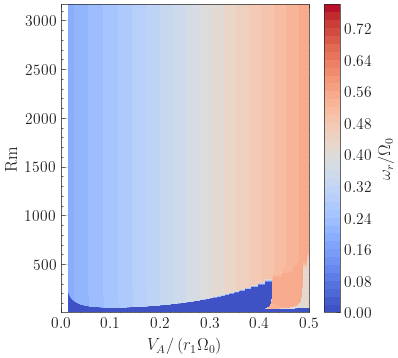

In [23]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1570, len(eta_arr)))
gr_ijk_ii = np.zeros((1570, len(eta_arr)))
freq_ijk = np.zeros((1570, len(eta_arr)))

# gr_ijk = np.zeros((1569, len(eta_arr)))
# gr_ijk_ii = np.zeros((1569, len(eta_arr)))
# freq_ijk = np.zeros((1569, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

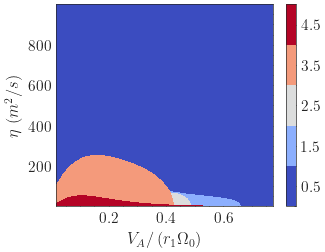

In [24]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()


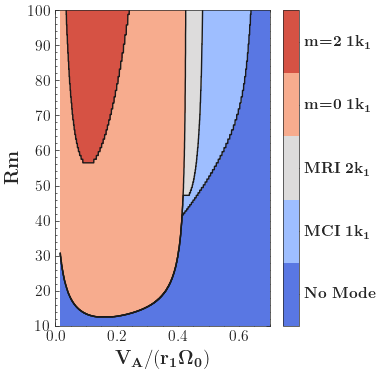

In [26]:
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# levels =np.array([0,1,2,3])
levels =np.array([0,1,2,3,4,5])

contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$',r'\textbf{m=0} $\mathbf{1k_1}$', r'\textbf{m=2} $\mathbf{1k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'm=0 $\mathbf{1k_1}$'])

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.ylim(10, 100)
plt.xlim(.0, 0.7)
plt.tight_layout()
plt.savefig('Rm-vA-Kep-PM' + PM_str + "-dommode-qmagpi-zoom-ms.pdf")

plt.show()

# Kep (1E-6, Fig 21, m0)

In [830]:
r1 = 0.1
dt = 1
PM_str = '1E-6'
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1',  'MRI_2k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1']
diff_modes = ['MCI_1k1',  'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1',  'MCI_2k1']

# diff_modes = ['MCI_1k1']
diff_modes = ['MCI_1k1', 'm0_1k1', 'm2_1k1']
# diff_modes = ['MCI_1k1', 'm0_1k1']
# diff_modes = ['m0_1k1']
# diff_modes = ['m0_1k1', 'm2_1k1']
# diff_modes = ['MCI_1k1', 'm2_1k1']

diff_modes = ['MCI_1k1', 'MCI_2k1', 'MRI_2k1','m0_1k1']

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 301, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 100, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 292, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MCI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            
        # if(diff_modes[k] == "m0_1k1"):
        #     guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        #     guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        #     VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        #     VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        if(diff_modes[k] == "m0_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
        if(diff_modes[k] == "m2_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    

eta_arr = np.arange(1, 1000, 1)
e11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
print(len(diff_modes))
print(len(eta_arr))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

4
999
(1570, 999, 4)


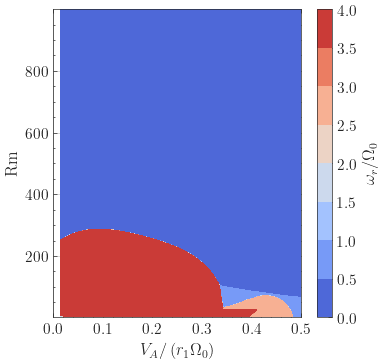

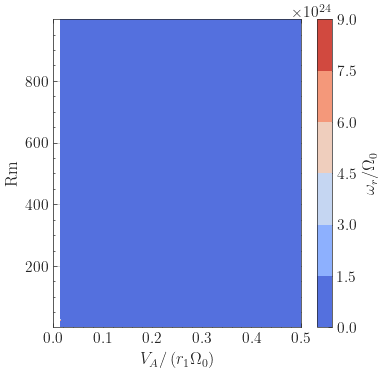

In [831]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1570, len(eta_arr)))
gr_ijk_ii = np.zeros((1570, len(eta_arr)))
freq_ijk = np.zeros((1570, len(eta_arr)))

# gr_ijk = np.zeros((1569, len(eta_arr)))
# gr_ijk_ii = np.zeros((1569, len(eta_arr)))
# freq_ijk = np.zeros((1569, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, eta_arr, np.transpose((gr_ijk_ii)), cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.xlim(0,0.5)
plt.show()

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, eta_arr, np.transpose((gr_ijk)), cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.xlim(0,0.5)
plt.show()

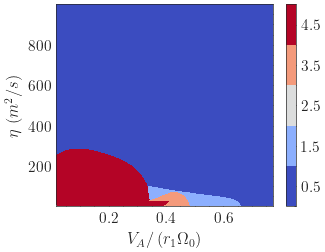

In [832]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()


In [833]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 4)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

286
0.07904916393815219
Minimum Rm: 11.056914895693634


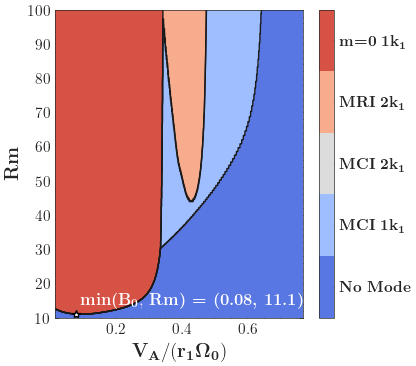

In [837]:
# import seaborn
# seaborn.set_theme()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# levels =np.array([0,1,2,3])
levels =np.array([0,1,2,3,4,5])

contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$',r'\textbf{m=0} $\mathbf{1k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'm=0 $\mathbf{1k_1}$'])


# plt.text(0.15, 30, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(VAm + 0.02, Rmm+3, r'\textbf{(min) = (0.08, 11.1)}', fontsize=13, color='w', fontweight='bold')
plt.text(VAm + 0.01, Rmm+3, r'\textbf{min(}$\mathbf{B_0,}$ \textbf{Rm) \textbf{= (0.08, 11.1)}', fontsize=12, color='w', fontweight='bold')

# plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
# plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')




# ax_inset = inset_axes(ax2, width="30%", height="25%", loc='upper right')
# ax_inset.axes.xaxis.set_ticklabels([])
# ax_inset.axes.yaxis.set_ticklabels([])
# ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 14, color = 'w')
# ax_inset.set_ylabel(r'$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$', fontsize = 14, color = 'w')
# ax_inset.plot(r_Kep_MCI, vr_MCI.real, color = color_arr[0])
# ax_inset.plot(r_Kep_MCI, vr_MCI.imag, color = color_arr[1])
# ax_inset.axvline(x=r_vec_Kep_MCI[0], linestyle = '--', color = 'green')
# ax_inset.axvline(x=r_vec_Kep_MCI[1], linestyle = '--', color = 'green')
# ax_inset.axvline(x=r_vec_Kep_MCI[4], linestyle = '-.', color = 'purple')
# ax_inset.set_xlim(0.9,5.1)
# ax_inset.text(0.45, 0.96, r'\textbf{(MCI)}', transform=ax_inset.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', color = 'purple')



lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.ylim(10, 100)
# plt.xlim(.0, 0.7)
# plt.tight_layout()
plt.savefig('Rm-vA-Kep-PM' + PM_str + "-dommode-qmagpi-zoom-FlowComp-m0.pdf")

plt.show()

# Kep (1E-6, Fig 21)

      converged: True
           flag: converged
 function_calls: 5
     iterations: 4
           root: (0.15353332843234332-0.0007717452596395849j)
         method: secant


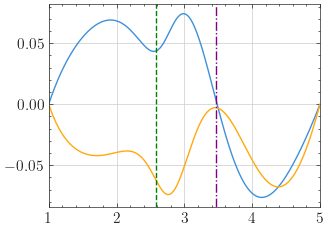

In [798]:
# Get mode structure for MRI 1k1 (Kep.)
##### SET PARAMETERS #####
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

r1 = 0.1
q = 1/2
type = 'MCI'
elecd = 159
eta = elecd
Pm = 1E-6
m = 1
kn = 1
kz = kn*np.pi/(4)
VA_N = 0.1322944755113183
Bz = VA_N*(r1*Omega0*np.sqrt(rho*mu_0)*10000)
B0 = 0
# ideal
guess = (0.1665665691533136+0.0323879597437419j)
# 
guess = (0.15397508409179786+0.00020129158792041714j)
    
r1 = 1
r2 = 5
r3 = 5.5
rp = np.linspace(0.1, r3, 50000)

r = np.linspace(r1, r2, 500)
q_mag = np.pi**2
q2r_sc = q_mag*1/r**2
q2rp_sc = q_mag*(-2/r**3)
q2rpp_sc = q_mag*(6/r**4)
q2i_sc = q_mag*np.zeros(len(r))
q2ip_sc = q_mag*np.zeros(len(r))
q2ipp_sc = q_mag*np.zeros(len(r))

ones_arr = np.ones(len(r)) 
k2 = (q2r_sc + 1j*q2i_sc) + m**2/r**2 + kz**2 * ones_arr
k2p = ((q2rp_sc + 1j*q2ip_sc) - 2 * m**2/r**3) ## just changed from d/dr
k2pp = ((q2rpp_sc + 1j*q2ipp_sc) + 6 * m**2/r**4) ## just changed from d/dr

k2r_curr = i2.CubicSpline(r, k2.real)
k2i_curr = i2.CubicSpline(r, k2.imag)
k2rp_curr = i2.CubicSpline(r, k2p.real)
k2ip_curr = i2.CubicSpline(r, k2p.imag)
k2rpp_curr = i2.CubicSpline(r, k2pp.real)
k2ipp_curr = i2.CubicSpline(r, k2pp.imag)


# ## SET CONDITIONS
# r1 = 0.1

# VA_N = 0.2
# Bz = VA_N*(r1*Omega0*np.sqrt(rho*mu_0)*10000)
# B0 = 0
# guess = (1.7321504394354405e-18+0.14627052038201555j)
# kn = 1
# m = 0
# kz = kn*np.pi/(4)

reso = 5000
############## Kep
##### SET PARAMETERS #####
flow_type = 'Kep'

if(flow_type == 'Kep'):
    flow_select = True
elif(flow_type == 'Tanh'):
    flow_select = 'tanh'
elif(flow_type == 'Sat'):
    flow_select = 'saturated'
elif(flow_type == 'Sh2'):
    flow_select = 'Sh2'

# guess = (1.3530621143324236e-18+0.01638527402078005j)
guess_MCI = guess
result = o.root_scalar(shoot_hain_v3, method='secant', x0=guess*(1.00005+1e-6j), x1=guess*(0.99995-1e-6j), args=(eta, k2r_curr, k2rp_curr, k2i_curr, k2ip_curr, kz, m, B0, Bz, flow_select, 1, r2,reso), maxiter=5000)
guess0 = result.root
y0 = [0.,(1.+1j)*1e-1]  
y = integ.solve_ivp(shoot_setup_hain_v2, [1,r2**2], y0, args=(guess0,eta, k2r_curr, k2rp_curr, k2i_curr, k2ip_curr, m,kz,B0,Bz,flow_select, 1), max_step=24./reso)
r_Kep_MCI = np.sqrt(y.t)
u_Kep_MCI = y.y[0]
r_vec_Kep_MCI = shr.resonance_res_krcomp_v8(r2, guess0, m, eta, Pm, k2r_curr, k2i_curr, kz, Bz, B0,flow_select, q)
print(result)


k2 = k2r_curr(r_Kep_MCI) + 1j*k2i_curr(r_Kep_MCI)
W = 1/r_Kep_MCI**(3/2)
lamb = -1j*guess
l_eta = lamb + 1j*m*W + eta/(r1**2*Omega0)*(k2)
vr_MCI = -l_eta*u_Kep_MCI/r_Kep_MCI

plt.figure()
plt.plot(r_Kep_MCI, vr_MCI.real, color = color_arr[0])
plt.plot(r_Kep_MCI, vr_MCI.imag, color = color_arr[1])
plt.axvline(x=r_vec_Kep_MCI[0], linestyle = '--', color = 'green', label = 'Resonance')
plt.axvline(x=r_vec_Kep_MCI[1], linestyle = '--', color = 'green')
plt.axvline(x=r_vec_Kep_MCI[4], linestyle = '-.', color = 'purple', label = 'Corotation')
plt.xlim(1,5)
plt.show()

In [799]:
r1 = 0.1
dt = 1
PM_str = '1E-6'
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []
diff_modes = ['MCI_1k1', 'MCI_2k1',  'MRI_2k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1', 'MCI_2k1']
diff_modes = ['MCI_1k1',  'MCI_2k1', 'm0_1k1']
# diff_modes = ['MCI_1k1',  'MCI_2k1']

# diff_modes = ['MCI_1k1']
diff_modes = ['MCI_1k1', 'm0_1k1', 'm2_1k1']
# diff_modes = ['MCI_1k1', 'm0_1k1']
# diff_modes = ['m0_1k1']
# diff_modes = ['m0_1k1', 'm2_1k1']
# diff_modes = ['MCI_1k1', 'm2_1k1']

diff_modes = ['MCI_1k1',  'MCI_2k1', 'MRI_2k1']

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 301, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 100, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 292, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v2-PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MCI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-v3-PM' + PM_str + '.pkl'
            
        # if(diff_modes[k] == "m0_1k1"):
        #     guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        #     guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        #     VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        #     VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '-v2.pkl'
        if(diff_modes[k] == "m0_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
        if(diff_modes[k] == "m2_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-kep-Bz-res-divr-q2magpisq-PM' + PM_str + '.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    

eta_arr = np.arange(1, 1000, 1)
e11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1570, len(eta_arr), len(diff_modes)))
print(len(diff_modes))
print(len(eta_arr))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

3
999
(1570, 999, 3)


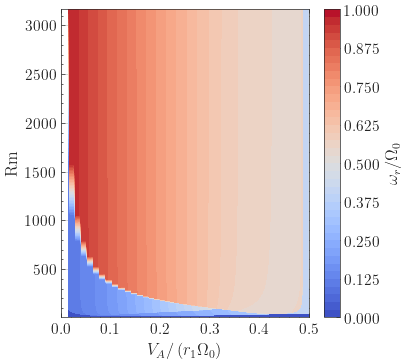

In [800]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1570, len(eta_arr)))
gr_ijk_ii = np.zeros((1570, len(eta_arr)))
freq_ijk = np.zeros((1570, len(eta_arr)))

# gr_ijk = np.zeros((1569, len(eta_arr)))
# gr_ijk_ii = np.zeros((1569, len(eta_arr)))
# freq_ijk = np.zeros((1569, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

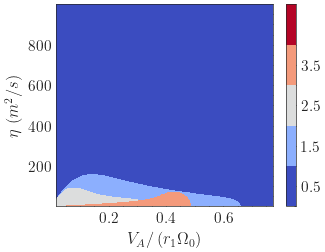

In [801]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

In [802]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 1)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

159
0.1322944755113183
Minimum Rm: 19.888538743197355


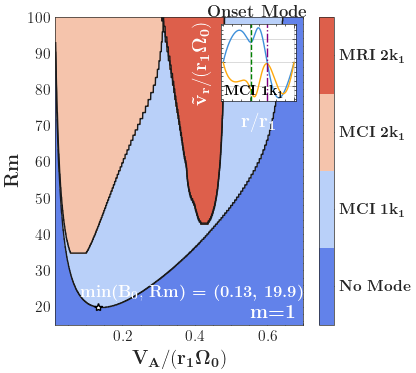

In [817]:
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# levels =np.array([0,1,2,3])
levels =np.array([0,1,2,3,4])

contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$',r'\textbf{MRI} $\mathbf{2k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'm=0 $\mathbf{1k_1}$'])



# plt.text(0.15, 30, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(VAm + 0.02, Rmm+3, r'\textbf{(min) = (0.13, 19.9)}', fontsize=13, color='w', fontweight='bold')
plt.text(VAm - 0.05, Rmm+3, r'\textbf{min(}$\mathbf{B_0,}$ \textbf{Rm) \textbf{= (0.13, 19.9)}', fontsize=12, color='w', fontweight='bold')

# plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
# plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')



plt.text(VAm + 0.42, Rmm-3, r'\textbf{m=1}', fontsize=14, color='w', fontweight='bold')

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.ylim(15, 100)
plt.xlim(.015, 0.7)

# plt.tight_layout()

ax_inset = inset_axes(ax2, width="30%", height="25%", loc='upper right')
ax_inset.axes.xaxis.set_ticklabels([])
ax_inset.axes.yaxis.set_ticklabels([])
ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 14, color = 'w')
ax_inset.set_ylabel(r'$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$', fontsize = 14, color = 'w')
ax_inset.plot(r_Kep_MCI, vr_MCI.real, color = color_arr[0])
ax_inset.plot(r_Kep_MCI, vr_MCI.imag, color = color_arr[1])
ax_inset.axvline(x=r_vec_Kep_MCI[0], linestyle = '--', color = 'green')
ax_inset.axvline(x=r_vec_Kep_MCI[1], linestyle = '--', color = 'green')
ax_inset.axvline(x=r_vec_Kep_MCI[4], linestyle = '-.', color = 'purple')
ax_inset.set_xlim(0.9,5.1)
ax_inset.text(0.04, 0.2, r'\textbf{MCI} $\mathbf{1k_1}$', transform=ax_inset.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', color = 'black')
# ax_inset.text(0.04, 0.9, r'\textbf{Onset}', transform=ax_inset.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', color = 'black')
ax_inset.set_title(r'\textbf{Onset Mode}')

# plt.tight_layout()
plt.savefig('Rm-vA-Kep-PM' + PM_str + "-dommode-qmagpi-zoom-FlowComp.pdf")

plt.show()

# Exp3 (1E-6, Fig21, m0)

In [824]:
r1 = 0.1
dt = 1
PM_str = '1E-6'
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []

diff_modes = ['MCI_1k1', 'm0_1k1', 'm2_1k1']
diff_modes = ['MCI_1k1',  'MRI_2k1', 'm0_1k1']
diff_modes = ['MCI_1k1','MCI_2k1',  'MRI_2k1', 'm0_1k1']
diff_modes = ['MCI_1k1','MCI_2k1',  'MRI_2k1']

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 71, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 45, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 1254, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MCI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        if(diff_modes[k] == "m0_1k1"):
            if j <= 1169:
                # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'    
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'                 
            else:
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        if(j == 1160):
            GL = guesses_1k1_MCI_l
            GH = guesses_1k1_MCI_h
            VL = VA_l_MCI1_Bz_ETA1_divr_WKB_div4
            VH = VA_h_MCI1_Bz_ETA1_divr_WKB_div4

        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    

# eta_arr = np.arange(1, 1000, 1)
# e11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
# f11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
# print(len(diff_modes))
# print(len(eta_arr))
# print(np.shape(e11))
# for k in range(0,len(diff_modes)):
#     len_eta = len(e[k])
#     for j in range(0,len_eta):
#         e11[0:len(e[k][j]),j,k] = e[k][j][:]
#         f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

eta_arr = np.arange(1, 2000, 1)
e11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        
        if(diff_modes[k] == 'm0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]


(1506, 1999, 3)


In [825]:
r1 = 0.1
dt = 1
PM_str = '1E-6'
eta_arr = np.arange(dt, 2000, dt)
e = []
f1 = []

diff_modes = ['MCI_1k1', 'm0_1k1', 'm2_1k1']
diff_modes = ['MCI_1k1',  'MCI_2k1', 'MRI_2k1', 'm0_1k1']
# diff_modes = ['MCI_2k1']

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 372, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 45, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 1254, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MCI_1k1"):
            if(j < 151):
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            else:
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'

        if(diff_modes[k] == "MCI_2k1"):
            if(j < 350):
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
            else:
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
        if(diff_modes[k] == "m0_1k1"):
            if j <= 1169:
                # guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                # guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                # VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                # VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'    
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'b.pkl'                 
            else:
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + 'c.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    

eta_arr = np.arange(1, 2000, 1)
e11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        
        if(diff_modes[k] == 'm0_1k1' or diff_modes[k] == 'm=0_2k1' or diff_modes[k] == 'm=0_3k1' ):
            # print(len(e[k][j]))
            len_diff = len(e[0][0]) - len(e[k][j])
            # print(len_diff)
            e11[len_diff:len(e[0][0]),j,k] = e[k][j][:]
            f11[len_diff:len(f1[0][0]),j,k] = f1[k][j][:]
        else:
            e11[0:len(e[k][j]),j,k] = e[k][j][:]
            f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

(1506, 1999, 4)


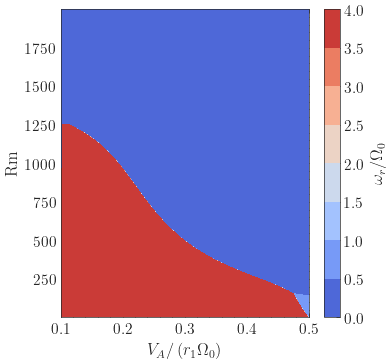

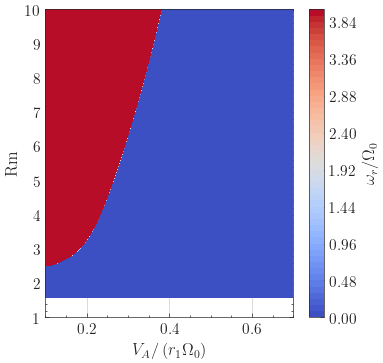

In [826]:
e11_ii = np.where(e11 <= 0)

e11_ii = np.where(e11 <= 1E-5)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1506, len(eta_arr)))
gr_ijk_ii = np.zeros((1506, len(eta_arr)))
freq_ijk = np.zeros((1506, len(eta_arr)))

# gr_ijk = np.zeros((1569, len(eta_arr)))
# gr_ijk_ii = np.zeros((1569, len(eta_arr)))
# freq_ijk = np.zeros((1569, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, eta_arr, np.transpose((gr_ijk_ii)), cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.xlim(0.1,0.5)
plt.show()

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, r1**2*Omega0/eta_arr, np.transpose((gr_ijk_ii)), cmap ='coolwarm', levels = 50)
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
cbar = plt.colorbar()
cbar.set_label(r'$\omega_r/\Omega_0$')
plt.xlim(0.1,0.7)
plt.ylim(1,10)
plt.show()



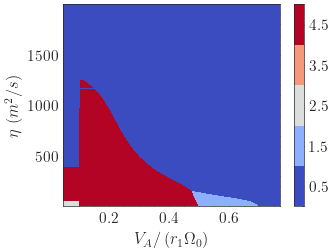

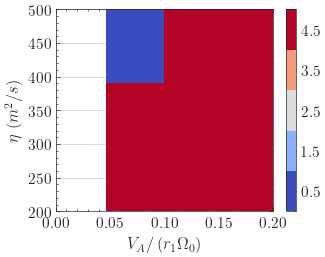

In [827]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.xlim(0,0.2)
plt.ylim(200,500)
plt.show()

In [828]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 4)


VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]

VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')


print(np.where(eta_arr == Rmm))
# print(gr_ijk[kk][jj])

1253
0.10337404968028699
Minimum Rm: 2.5237650919141097
(array([], dtype=int64),)


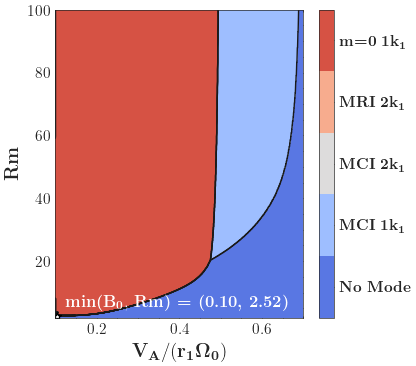

In [829]:
# import seaborn
# seaborn.set_theme()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# levels =np.array([0,1,2,3])
levels =np.array([0,1,2,3,4,5])

contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3,4])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$',r'\textbf{MRI} $\mathbf{2k_1}$',r'\textbf{m=0} $\mathbf{1k_1}$'])
# cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$',r'\textbf{MRI} $\mathbf{2k_1}$'])


plt.text(VAm + 0.02, Rmm+3, r'\textbf{min(}$\mathbf{B_0,}$ \textbf{Rm) \textbf{= (0.10, 2.52)}', fontsize=12, color='w', fontweight='bold')
# plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
# plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')


lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.ylim(2, 100)
plt.xlim(0.1, 0.7)
# plt.tight_layout()
plt.savefig('Rm-vA-Exp3-PM' + PM_str + "-dommode-qmagpi-zoom-FlowComp-m0.pdf")

plt.show()

# Exp3 (1E-6, Fig21)

      converged: True
           flag: converged
 function_calls: 17
     iterations: 16
           root: (0.18907070173455226+5.845112158956646e-05j)
         method: secant


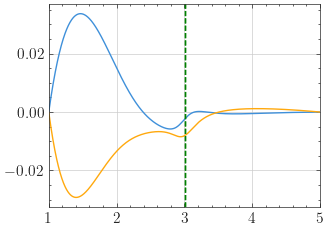

In [818]:
# Get mode structure for MRI 1k1 (Kep.)
##### SET PARAMETERS #####
color_arr = ['#3F90DA', '#FFA90E', '#BD1F01', '#94A4A2', '#832DB6', '#A96B59', '#E76300', '#B9AC70', '#92DADD']

r1 = 0.1
q = 1/2
type = 'MCI'
elecd = 371
eta = elecd
Pm = 1E-6
m = 1
kn = 2
kz = kn*np.pi/(4)
VA_N = 0.07181905748039437
Bz = VA_N*(r1*Omega0*np.sqrt(rho*mu_0)*10000)
B0 = 0
# ideal
guess = (0.1665665691533136+0.0323879597437419j)
# 
guess = (0.15397508409179786+0.00020129158792041714j)
    
r1 = 1
r2 = 5
r3 = 5.5
rp = np.linspace(0.1, r3, 50000)

r = np.linspace(r1, r2, 500)
q_mag = np.pi**2
q2r_sc = q_mag*1/r**2
q2rp_sc = q_mag*(-2/r**3)
q2rpp_sc = q_mag*(6/r**4)
q2i_sc = q_mag*np.zeros(len(r))
q2ip_sc = q_mag*np.zeros(len(r))
q2ipp_sc = q_mag*np.zeros(len(r))

ones_arr = np.ones(len(r)) 
k2 = (q2r_sc + 1j*q2i_sc) + m**2/r**2 + kz**2 * ones_arr
k2p = ((q2rp_sc + 1j*q2ip_sc) - 2 * m**2/r**3) ## just changed from d/dr
k2pp = ((q2rpp_sc + 1j*q2ipp_sc) + 6 * m**2/r**4) ## just changed from d/dr

k2r_curr = i2.CubicSpline(r, k2.real)
k2i_curr = i2.CubicSpline(r, k2.imag)
k2rp_curr = i2.CubicSpline(r, k2p.real)
k2ip_curr = i2.CubicSpline(r, k2p.imag)
k2rpp_curr = i2.CubicSpline(r, k2pp.real)
k2ipp_curr = i2.CubicSpline(r, k2pp.imag)


# ## SET CONDITIONS
# r1 = 0.1

# VA_N = 0.2
# Bz = VA_N*(r1*Omega0*np.sqrt(rho*mu_0)*10000)
# B0 = 0
# guess = (1.7321504394354405e-18+0.14627052038201555j)
# kn = 1
# m = 0
# kz = kn*np.pi/(4)

reso = 5000
############## Kep
##### SET PARAMETERS #####
flow_type = 'Exp3'

if(flow_type == 'Kep'):
    flow_select = True
elif(flow_type == 'Tanh'):
    flow_select = 'tanh'
elif(flow_type == 'Sat'):
    flow_select = 'saturated'
elif(flow_type == 'Sh2'):
    flow_select = 'Sh2'

flow_select = 'exp6'
# guess = (1.3530621143324236e-18+0.01638527402078005j)
guess_MCI = guess
result = o.root_scalar(shoot_hain_v3, method='secant', x0=guess*(1.00005+1e-6j), x1=guess*(0.99995-1e-6j), args=(eta, k2r_curr, k2rp_curr, k2i_curr, k2ip_curr, kz, m, B0, Bz, flow_select, 1, r2,reso), maxiter=5000)
guess0 = result.root
y0 = [0.,(1.+1j)*1e-1]  
y = integ.solve_ivp(shoot_setup_hain_v2, [1,r2**2], y0, args=(guess0,eta, k2r_curr, k2rp_curr, k2i_curr, k2ip_curr, m,kz,B0,Bz,flow_select, 1), max_step=24./reso)
r_Kep_MCI = np.sqrt(y.t)
u_Kep_MCI = y.y[0]
r_vec_Kep_MCI = shr.resonance_res_krcomp_v8(r2, guess0, m, eta, Pm, k2r_curr, k2i_curr, kz, Bz, B0,flow_select, q)
print(result)


k2 = k2r_curr(r_Kep_MCI) + 1j*k2i_curr(r_Kep_MCI)
W = 1/r_Kep_MCI**(3/2)
lamb = -1j*guess
l_eta = lamb + 1j*m*W + eta/(r1**2*Omega0)*(k2)
vr_MCI = -l_eta*u_Kep_MCI/r_Kep_MCI

plt.figure()
plt.plot(r_Kep_MCI, vr_MCI.real, color = color_arr[0])
plt.plot(r_Kep_MCI, vr_MCI.imag, color = color_arr[1])
plt.axvline(x=r_vec_Kep_MCI[0], linestyle = '--', color = 'green', label = 'Resonance')
plt.axvline(x=r_vec_Kep_MCI[1], linestyle = '--', color = 'green')
# plt.axvline(x=r_vec_Kep_MCI[4], linestyle = '-.', color = 'purple', label = 'Corotation')
plt.xlim(1,5)
plt.show()

In [819]:
r1 = 0.1
dt = 1
PM_str = '1E-6'
eta_arr = np.arange(dt, 500, dt)
e = []
f1 = []

diff_modes = ['MCI_1k1', 'm0_1k1', 'm2_1k1']
diff_modes = ['MCI_1k1',  'MCI_2k1', 'MRI_2k1']
# diff_modes = ['MCI_2k1']

for k in range(0,len(diff_modes)):
    d = []
    d1 = []

    if(diff_modes[k] == 'MCI_1k1'):
        eta_arr = np.arange(1, 500, 1)
    elif(diff_modes[k] == 'MCI_2k1'):
        eta_arr = np.arange(1, 372, 1)
    elif(diff_modes[k] == 'MRI_1k1'):
        eta_arr = np.arange(1, 4, 1)
    elif(diff_modes[k] == 'MRI_2k1'):
        eta_arr = np.arange(1, 45, 1)
    elif(diff_modes[k] == 'm0_1k1'):
        eta_arr = np.arange(1, 500, 1)
    n = 0
    for j in eta_arr:
        elecd_str = f'{j}'
    
        guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
        VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MRI_2k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'

        if(diff_modes[k] == "MCI_1k1"):
            if(j < 151):
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            else:
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-2.pkl'

        if(diff_modes[k] == "MCI_2k1"):
            if(j < 350):
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-3.pkl'
            else:
                guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
                guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
                VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
                VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '-4.pkl'
        if(diff_modes[k] == "m0_1k1"):
            guesses_str_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesu_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            guesses_str_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_guessesd_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_u = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANUP_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'
            VA_d = f'Shooting-AlfvenSweep-Scaled-Data/' + diff_modes[k] + '_VANDOWN_' + elecd_str + '-Exp6-q2pi_PM' + PM_str + '.pkl'

        with open(guesses_str_d, 'rb') as f:
            guesses_1k1_MCI_l = pickle.load(f)    
        with open(guesses_str_u, 'rb') as f:
            guesses_1k1_MCI_h = pickle.load(f)    
        
        with open(VA_d, 'rb') as f:
            VA_l_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)    
        with open(VA_u, 'rb') as f:
            VA_h_MCI1_Bz_ETA1_divr_WKB_div4 = pickle.load(f)   
            
        gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4= []
        gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].imag)
        for j in range(0,len(guesses_1k1_MCI_h) ):
            gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].imag)    
        freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4 = []
        freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4 = []
        for j in range(0,len(guesses_1k1_MCI_l)):
            freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_l[j].real)
            
        for j in range(0,len(guesses_1k1_MCI_h)):
            freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4.append(guesses_1k1_MCI_h[j].real)
        
        e12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        f12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        VA12 = np.zeros(len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4) - 1)
        e12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(gr_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        f12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(freq_1k1_MCI_l_Bz_ETA1_divr_WKB_div4[:])
        VA12[0:len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4)] = np.flip(VA_l_MCI1_Bz_ETA1_divr_WKB_div4[:])
        e12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        f12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = freq_1k1_MCI_h_Bz_ETA1_divr_WKB_div4[1:len(gr_1k1_MCI_h_Bz_ETA1_divr_WKB_div4)]
        VA12[len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4):len(VA_l_MCI1_Bz_ETA1_divr_WKB_div4) + len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)-1] = VA_h_MCI1_Bz_ETA1_divr_WKB_div4[1:len(VA_h_MCI1_Bz_ETA1_divr_WKB_div4)]
        if(k == 0):
            VA_N_total = VA12
        if(len(VA12) > len(VA_N_total)):
            VA_N_total = VA12
        gr_tot = e12
        n = n + 1

        d.append(gr_tot)
        d1.append(f12)
    e.append(d)
    f1.append(d1)
    

eta_arr = np.arange(1, 1500, 1)
e11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
f11 = np.zeros((1506, len(eta_arr), len(diff_modes)))
print(len(diff_modes))
print(len(eta_arr))
print(np.shape(e11))
for k in range(0,len(diff_modes)):
    len_eta = len(e[k])
    for j in range(0,len_eta):
        e11[0:len(e[k][j]),j,k] = e[k][j][:]
        f11[0:len(f1[k][j]),j,k] = f1[k][j][:]

3
1499
(1506, 1499, 3)


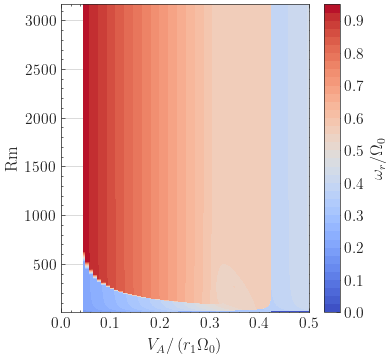

In [820]:
e11_ii = np.where(e11 <= 0)
e11[e11_ii[:]] = 0

### Take slices of maximum gr at given freq:
gr_ijk = np.zeros((1506, len(eta_arr)))
gr_ijk_ii = np.zeros((1506, len(eta_arr)))
freq_ijk = np.zeros((1506, len(eta_arr)))

# gr_ijk = np.zeros((1569, len(eta_arr)))
# gr_ijk_ii = np.zeros((1569, len(eta_arr)))
# freq_ijk = np.zeros((1569, len(eta_arr)))

for i in range(0,np.shape(e11)[0]):
    for j in range(0,np.shape(e11)[1]):
        for k in range(0,np.shape(e11)[2]):
            # gr_ijk[i,j] = e11[i,j,k]
            if(e11[i,j,k] > gr_ijk[i,j]):
                # gr_ijk[i,j] = e11[i,j,k]
                gr_ijk_ii[i,j] = k+1
                freq_ijk[i,j] = f11[i,j,k]
                if(freq_ijk[i,j] < 0.001):
                    freq_ijk[i,j] = 0
                # print(diff_modes[k])
                # print(k)
            
Rm = r1**2*Omega0/eta_arr

fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
fig.set_figheight(4)
fig.set_figwidth(4)

plt.contourf(VA_N_total, Rm, np.transpose((freq_ijk)),40, cmap ='coolwarm')
plt.ylabel(r'Rm')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
# Add a colorbar
cbar = plt.colorbar()
# Add a label to the colorbar
cbar.set_label(r'$\omega_r/\Omega_0$')
# plt.title(r'Dominant Mode at fixed Rm and $V_A$')
plt.xlim(0,0.5)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.png', dpi = 400)
# plt.savefig('Rm-vA-Kep-3r1-freq-qmagpi.svg', format = 'svg')
plt.show()

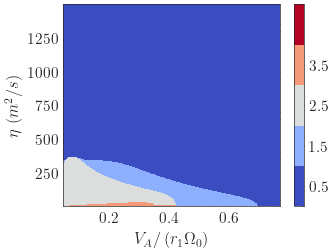

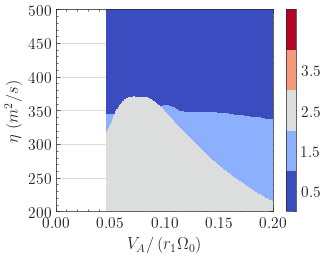

In [821]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
# x and y are bounds, so z should be the value *inside* those bounds.
# Therefore, remove the last value from the z array.
gr_ijk_ii_plot = np.transpose(gr_ijk_ii)

nticks = len(diff_modes) 
levels_arr = np.zeros(len(diff_modes)+1)
ticks_arr = np.zeros(len(diff_modes)+1)
for j in range(0, len(diff_modes)+1):
    ticks_arr[j] = j
    levels_arr[j] = j


ticks_arr = ticks_arr +0.5
levels = [0,1,2,3,4,5]
cmap = plt.colormaps['coolwarm']
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.show()

plt.figure()
contour = plt.pcolormesh(VA_N_total, eta_arr, gr_ijk_ii_plot, cmap=cmap, norm=norm)
# plt.contourf(VA_N_total, eta_arr, gr_ijk_ii_plot)
# cbar = plt.colorbar(im, ax=ax0)
cbar = plt.colorbar(contour,  ticks=ticks_arr)
# cbar.ax.set_yticklabels(['No Mode', r'MCI $1k_1$', r'MCI $2k_1$', r'MRI $1k_1$', r'MRI $2k_1$'])
plt.ylabel(r'$\eta$  $(m^2/s)$')
plt.xlabel(r'$V_A/\left(r_1\Omega_0\right)$')
plt.xlim(0,0.2)
plt.ylim(200,500)
plt.show()


In [822]:
j_mark = 0
k_mark = 0
gr_ii = np.where(gr_ijk_ii_plot == 2)
# print(gr_ii)
# print(np.where(gr_ii[0] == np.max(gr_ii[0])))
# print(gr_ii)

VA_N_total[gr_ii[1][:]]
# print(eta_arr[gr_ii[0][:]])
print(np.max((eta_arr[gr_ii[0][:]])))
jj = np.where(eta_arr[gr_ii[0][:]] == np.max(eta_arr[gr_ii[0][:]]))
# print(jj)
kk = VA_N_total[gr_ii[1][:]][jj[:]]
# print(kk)
# VAm = VA_N_total[jj[:]][0]
# VAm = VA_N_total[gr_ii[1][:]][jj[:]][0]
# VAm = VA_N_total[jj[:]][0]
VAm = kk[0]
print(VAm)
Rmm = r1**2*Omega0/np.max((eta_arr[gr_ii[0][:]]))
print(f'Minimum Rm: {Rmm}')

371
0.07181905748039437
Minimum Rm: 8.523659461370295


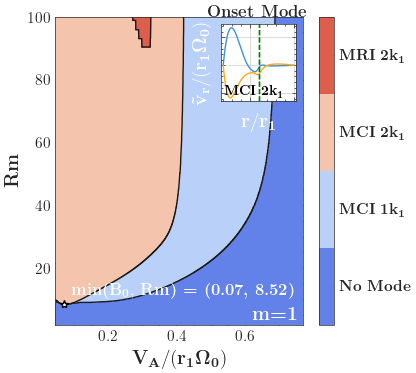

In [823]:
# import seaborn
# seaborn.set_theme()
cmap = 'coolwarm'
fig,ax2 = plt.subplots(1)
ax2.set(xlabel=r'$V_A/(r_1\Omega_0)$', ylabel=r"Rm")
ax2.set_xlabel(r'$\mathbf{V_A/(r_1\Omega_0)}$', fontsize = 14)
ax2.set_ylabel(r'\textbf{Rm}', fontsize = 14)
# ax2.set_ylabel(r'Rm', fontsize = 14)

fig.set_figheight(4)
fig.set_figwidth(4)

levels = [0,1,2,3,4,5,6,7,8]

# contour = plt.pcolormesh(VA_N_total, Rm, gr_ijk_ii_plot, cmap=cmap, norm=norm, rasterized=True)
# levels =np.array([0,1,2,3])
levels =np.array([0,1,2,3,4])

contour = plt.contourf(VA_N_total, Rm, gr_ijk_ii_plot+1., cmap=cmap, levels = levels)
plt.contour(contour, colors='k')

tickss = np.array([0,1,2,3])+ 0.5
cbar = plt.colorbar(contour,  ticks=tickss) 
# cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$', r'\textbf{MRI} $\mathbf{2k_1}$'])
cbar.ax.set_yticklabels([r'\textbf{No Mode}', r'\textbf{MCI} $\mathbf{1k_1}$', r'\textbf{MCI} $\mathbf{2k_1}$',r'\textbf{MRI} $\mathbf{2k_1}$'])
# cbar.ax.set_yticklabels([r'No Mode', r'MCI $\mathbf{1k_1}$', r'm=0 $\mathbf{1k_1}$'])



# plt.text(0.15, 30, f'(min) = ({np.round(VAm,1)}, {np.round(Rmm,1)})', fontsize=12, color = 'w', weight = 'extra bold')
# plt.text(VAm + 0.02, Rmm+3, r'\textbf{(min) = (0.07, 8.5)}', fontsize=13, color='w', fontweight='bold')
plt.text(VAm + 0.02, Rmm+3, r'\textbf{min(}$\mathbf{B_0,}$ \textbf{Rm) \textbf{= (0.07, 8.52)}', fontsize=12, color='w', fontweight='bold')


# plt.axvline(x = VAm, color = 'w', linestyle = 'dashed')
# plt.axhline(y = Rmm, color = 'w', linestyle = 'dashed')
plt.plot(VAm, Rmm, color = 'w', marker = '*', markeredgecolor='black')
plt.text(VAm + 0.55, Rmm-5, r'\textbf{m=1}', fontsize=14, color='w', fontweight='bold')

lines_labels = [ax2.get_legend_handles_labels() for ax2 in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.ylim(2, 100)
# plt.xlim(.0, 0.7)

ax_inset = inset_axes(ax2, width="30%", height="25%", loc='upper right')
ax_inset.axes.xaxis.set_ticklabels([])
ax_inset.axes.yaxis.set_ticklabels([])
ax_inset.set_xlabel(r'$\mathbf{r/r_1}$', fontsize = 14, color = 'w')
ax_inset.set_ylabel(r'$\mathbf{\tilde{v}_r/(r_1\Omega_0)}$', fontsize = 14, color = 'w')
ax_inset.plot(r_Kep_MCI, vr_MCI.real, color = color_arr[0])
ax_inset.plot(r_Kep_MCI, vr_MCI.imag, color = color_arr[1])
ax_inset.axvline(x=r_vec_Kep_MCI[0], linestyle = '--', color = 'green')
ax_inset.axvline(x=r_vec_Kep_MCI[1], linestyle = '--', color = 'green')
# ax_inset.axvline(x=r_vec_Kep_MCI[4], linestyle = '-.', color = 'purple')
ax_inset.set_xlim(0.9,5.1)
ax_inset.text(0.04, 0.2, r'\textbf{MCI} $\mathbf{2k_1}$', transform=ax_inset.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', color = 'black')
ax_inset.set_title(r'\textbf{Onset Mode}')


# plt.tight_layout()
plt.savefig('Rm-vA-Exp3-PM' + PM_str + "-dommode-qmagpi-zoom-FlowComp.pdf")

plt.show()